# 18. Cross-Species Peak–Gene Correlation Analysis

Uses the pseudobulk Pearson rho database from notebook 17 to:
1. Confirm database quality with Human vs SCENIC+ single-cell rho
2. Grid scatter: Human rho vs every NHP species
3. Discover human-specific links (high Human rho, absent in NHPs)
4. Discover conserved links (high rho in all species)
5. For top candidates: visualise cell-type-level ATAC + RNA signal

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Publication style
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.family': 'sans-serif',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 150,
})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top']   = False

In [20]:
SPECIES  = ["Human", "Gorilla", "Chimpanzee", "Bonobo", "Marmoset", "Macaque"]
NHP      = [s for s in SPECIES if s != "Human"]

RHO_DB_DIR   = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/17_peak_gene_rho_db")
FRAGS_DIR    = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/12_fragment_matrices")
RNA_PATH     = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/rna/integration/scvi_integration/nhp_atlas_merged_scvi_input_20250520_112026.h5ad")
MASTER_ANNOT = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/07_master_annotation/master_annotation_final.tsv")
OUT_DIR      = RHO_DB_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True)

# ── Species colours ───────────────────────────────────────────────────────────
SPECIES_COLORS = {
    'Human':      '#43A047',
    'Chimpanzee': '#FCB216',
    'Bonobo':     '#1A889D',
    'Gorilla':    '#892782',
    'Macaque':    '#EF476F',
    'Marmoset':   '#F36F21',
}

# ── Cell-type colours ────────────────────────────────────────────────────────
CELL_TYPE_COLORS = {
    'Enterocytes': '#D95B27', 'Colonocytes': '#DA5C2D', 'TA cells': '#F5865F',
    'BEST4 cells': '#913C1F', 'BEST4+ cells': '#913C1F',
    'Fibroblasts SYNM+': '#E59825', 'Fibroblasts RSPO2/3+': '#FCB137',
    'Myofibroblasts': '#AA732A', 'Fibroblasts PCDH9+': '#A8762B',
    'Fibroblasts RALYL+': '#8C411E', 'Fibroblasts RSPO3+': '#FECC81',
    'Crypt Fibroblasts WNT2B+': '#AB7B2C', 'Enteric glia': '#F05653',
    'Fibroblasts ADAMTS16+': '#533B16', 'Villus Fibroblasts WNT5B+': '#FDC172',
    'Fibroblasts VCAM1+': '#F7AF1A', 'Fibroblasts KCNN3+': '#F4C068',
    'ICCs': '#DA9C28', 'Goblet cells': '#A14223', 'Paneth cells': '#F7956F',
    'Stem cells': '#F6967B', 'Tuft cells': '#F8A488', 'Enteric neurons': '#93292A',
    'Pericytes': '#FECE92', 'Mast cells': '#872890', 'Mesothelial cells': '#FDD7A4',
    'ECs': '#327338', 'NK/ILCs': '#822989', 'Eosinophils': '#B975B1',
    'Neutrophils': '#852990', 'T cells': '#CD7AB2', 'Lymphatic ECs': '#64BB67',
    'RBP2 high cells': '#8E191D', 'MARCO+ Lymphatic ECs': '#238842',
    'Adipocytes': '#895422', 'Naive B Cells': '#A9459A', 'Naive B cells': '#A9459A',
    'MUC6+ cells': '#D1643D', 'EECs': '#B25A27',
    'Macrophages': '#822989', 'Monocytes': '#9B59B6', 'Plasma B cells': '#8E44AD',
}

# ── Broad-class colours ───────────────────────────────────────────────────────
BROAD_CLASS_COLORS = {
    'Epithelial': '#D24627', 'Immune': '#A54A9C',
    'Neuronal': '#D42027', 'Endothelial': '#377639', 'Mesenchymal': '#D69E28',
}

CELL_TYPE_MAP = {
    'BEST4+ cells': 'Epithelial', 'BEST4 cells': 'Epithelial',
    'Colonocytes': 'Epithelial', 'EECs': 'Epithelial',
    'Enterocytes': 'Epithelial', 'Goblet cells': 'Epithelial',
    'MUC6+ cells': 'Epithelial', 'Paneth cells': 'Epithelial',
    'RBP2 high cells': 'Epithelial', 'Stem cells': 'Epithelial',
    'TA cells': 'Epithelial', 'Tuft cells': 'Epithelial',
    'Adipocytes': 'Mesenchymal', 'Crypt Fibroblasts WNT2B+': 'Mesenchymal',
    'Fibroblasts ADAMTS16+': 'Mesenchymal', 'Fibroblasts KCNN3+': 'Mesenchymal',
    'Fibroblasts PCDH9+': 'Mesenchymal', 'Fibroblasts RALYL+': 'Mesenchymal',
    'Fibroblasts RSPO2/3+': 'Mesenchymal', 'Fibroblasts RSPO3+': 'Mesenchymal',
    'Fibroblasts SYNM+': 'Mesenchymal', 'Fibroblasts VCAM1+': 'Mesenchymal',
    'ICCs': 'Mesenchymal', 'Mesothelial cells': 'Mesenchymal',
    'Myofibroblasts': 'Mesenchymal', 'Pericytes': 'Mesenchymal',
    'Villus Fibroblasts WNT5B+': 'Mesenchymal',
    'Eosinophils': 'Immune', 'Macrophages': 'Immune', 'Mast cells': 'Immune',
    'Monocytes': 'Immune', 'Naive B Cells': 'Immune', 'Naive B cells': 'Immune',
    'Neutrophils': 'Immune', 'NK/ILCs': 'Immune',
    'Plasma B cells': 'Immune', 'T cells': 'Immune',
    'ECs': 'Endothelial', 'Lymphatic ECs': 'Endothelial',
    'MARCO+ Lymphatic ECs': 'Endothelial',
    'Enteric glia': 'Neuronal', 'Enteric neurons': 'Neuronal',
}

# Build lookup that handles both original names AND underscore/p-transformed names
# (the data stores e.g. "Crypt_Fibroblasts_WNT2Bp" instead of "Crypt Fibroblasts WNT2B+")
def _make_ct_lookup(color_dict):
    lookup = dict(color_dict)
    for name, color in color_dict.items():
        transformed = name.replace(" ", "_").replace("+", "p")
        lookup.setdefault(transformed, color)
    return lookup

CT_COLOR_LOOKUP = _make_ct_lookup(CELL_TYPE_COLORS)

REGION_COLORS = {'Duodenum': '#009481', 'Colon': '#C33956'}

print("Setup done.")

Setup done.


## 2. Load database and annotate peak types

In [3]:
print("Loading rho database...")
db_raw = pd.read_parquet(RHO_DB_DIR / "peak_gene_rho_database.parquet")

# Remove failed-mapping entries (peak_id == '-1' from pyranges unmatched)
db = db_raw[db_raw["peak_id"].astype(str) != "-1"].copy()
db = db[db["peak_id"].astype(str) != ""].copy()

rho_cols = [f"rho_{sp}" for sp in SPECIES]

# Recompute summary stats after filtering
db["rho_mean"]           = db[rho_cols].mean(axis=1)
db["rho_std"]            = db[rho_cols].std(axis=1)
db["rho_max"]            = db[rho_cols].max(axis=1)
db["rho_min"]            = db[rho_cols].min(axis=1)
db["n_species_with_rho"] = db[rho_cols].notna().sum(axis=1)

# Peak type from peak_id prefix
def classify_peak(pid):
    pid = str(pid)
    if pid.startswith("unified_"):      return "unified"
    if pid.startswith("human_peak_"):   return "human_specific"
    if pid.endswith("_rescued") or "rescued" in pid: return "rescued"
    return "species_specific"

db["peak_type"] = db["peak_id"].apply(classify_peak)

print(f"Database: {len(db):,} pairs")
print(db["peak_type"].value_counts().to_string())
print()
print("Coverage:")
for c in rho_cols:
    n = db[c].notna().sum()
    print(f"  {c}: {n:,} ({100*n/len(db):.1f}%) | |rho|>0.3: {(db[c].abs()>0.3).sum():,}")

Loading rho database...
Database: 4,877,586 pairs
unified             4699194
species_specific     169362
human_specific         9030

Coverage:
  rho_Human: 2,825,781 (57.9%) | |rho|>0.3: 233,225
  rho_Gorilla: 2,671,693 (54.8%) | |rho|>0.3: 143,899
  rho_Chimpanzee: 2,746,884 (56.3%) | |rho|>0.3: 185,696
  rho_Bonobo: 2,644,781 (54.2%) | |rho|>0.3: 84,247
  rho_Marmoset: 2,513,741 (51.5%) | |rho|>0.3: 251,637
  rho_Macaque: 2,668,489 (54.7%) | |rho|>0.3: 246,078


In [4]:
# For cross-species scatter we need pairs with rho in BOTH Human and the NHP
# Keep pairs where |rho_Human| > 0.1 OR |rho_NHP| > 0.1 (non-trivial in at least one species)
any_signal = (db[rho_cols].abs() > 0.1).any(axis=1)
db_sig = db[any_signal & db["rho_Human"].notna()].copy()
print(f"Pairs with |rho|>0.1 in at least one species and Human rho present: {len(db_sig):,}")

Pairs with |rho|>0.1 in at least one species and Human rho present: 2,720,850


## 3. Grid scatter: Human rho vs every NHP

In [21]:
def scatter_rho_panel(ax, df, sp, max_pts=60_000, rho_thr=0.3, highlight_hs=True):
    """Single panel: Human rho (x) vs NHP rho (y) for species sp."""
    col = f"rho_{sp}"
    sub = df[["rho_Human", col, "peak_type"]].dropna(subset=[col])

    conserved = sub[(sub["rho_Human"].abs() > rho_thr) & (sub[col].abs() > rho_thr)]
    diverged  = sub[(sub["rho_Human"].abs() > rho_thr) & (sub[col].abs() < 0.1)]
    bg        = sub[~sub.index.isin(conserved.index) & ~sub.index.isin(diverged.index)]

    if len(bg) > max_pts:
        bg = bg.sample(max_pts, random_state=42)

    ax.scatter(bg["rho_Human"], bg[col], s=1, alpha=0.15,
               color="#cccccc", rasterized=True, linewidths=0)
    ax.scatter(conserved["rho_Human"], conserved[col], s=1, alpha=0.6,
               color=SPECIES_COLORS[sp], rasterized=True, linewidths=0,
               label=f"Conserved (n={len(conserved):,})")
    if highlight_hs:
        ax.scatter(diverged["rho_Human"], diverged[col], s=1, alpha=0.7,
                   color=SPECIES_COLORS["Human"], rasterized=True, linewidths=0,
                   label=f"Human-enriched (n={len(diverged):,})")

    both = sub.dropna()
    r = both[["rho_Human", col]].corr().iloc[0, 1]

    ax.axhline(0, lw=0.4, color="k", ls="--", alpha=0.4)
    ax.axvline(0, lw=0.4, color="k", ls="--", alpha=0.4)
    ax.set_xlim(-0.85, 0.85)
    ax.set_ylim(-0.85, 0.85)
    ax.set_xlabel("Human rho")
    ax.set_ylabel(f"{sp} rho")
    ax.set_title(f"Human vs {sp}\nr = {r:.2f}", pad=4)

    return r, len(conserved), len(diverged)

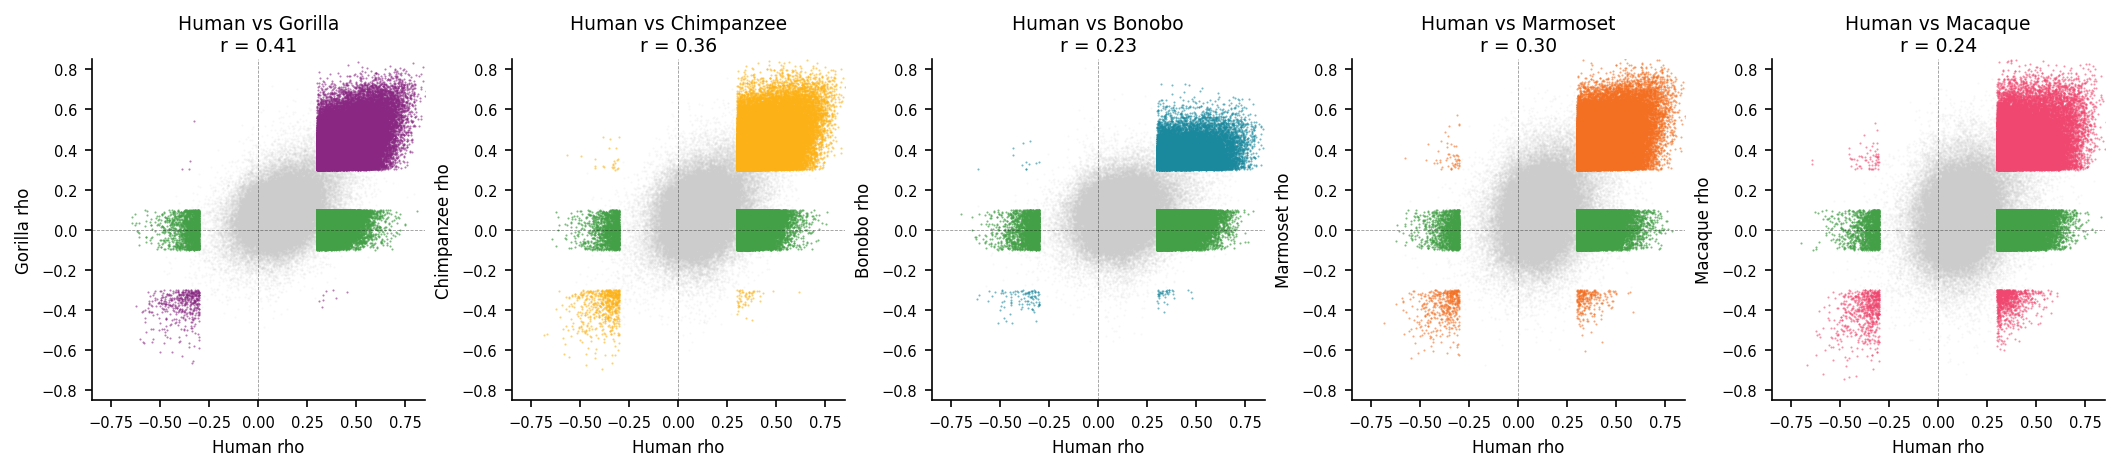


Stats per species:
                   r  n_conserved  n_human_enriched
Gorilla     0.412154      67594.0           45144.0
Chimpanzee  0.362240      69581.0           51138.0
Bonobo      0.231304      26623.0           72341.0
Marmoset    0.295200      69910.0           50404.0
Macaque     0.243375      54517.0           62789.0


In [24]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3.0), constrained_layout=True)

stats = {}
for ax, sp in zip(axes, NHP):
    r, n_cons, n_div = scatter_rho_panel(ax, db_sig, sp)
    stats[sp] = {"r": r, "n_conserved": n_cons, "n_human_enriched": n_div}

    # Legend only for first panel
    #if sp == NHP[0]:
    #    ax.legend(markerscale=4, frameon=False, loc="upper left")

# Shared colorbar-free legend strip
#fig.suptitle("Peak–Gene Correlation: Human vs Non-Human Primates\n"
#             "(pseudobulk Pearson rho, |rho|>0.1 in ≥1 species)",
#             fontsize=9, y=1.02)

plt.savefig(OUT_DIR / "Fig1_Human_vs_NHP_rho_grid.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "Fig1_Human_vs_NHP_rho_grid.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nStats per species:")
print(pd.DataFrame(stats).T.to_string())

## 4. Conserved and human-specific links

In [7]:
# ── Conserved: strong rho (>0.3) in Human AND ≥4 other species ──
nhp_rho_cols = [f"rho_{sp}" for sp in NHP]

db["n_nhp_strong"] = (db[nhp_rho_cols].abs() > 0.3).sum(axis=1)
db["nhp_rho_mean"] = db[nhp_rho_cols].mean(axis=1)
db["nhp_rho_min"]  = db[nhp_rho_cols].min(axis=1)

conserved = db[
    (db["rho_Human"].abs() > 0.3) &
    (db["n_nhp_strong"] >= 4) &
    (db["rho_Human"] * db["nhp_rho_mean"] > 0)  # same sign
].copy()
conserved["score"] = conserved[rho_cols].abs().mean(axis=1)
conserved = conserved.sort_values("score", ascending=False)

print(f"Conserved links (|rho_Human|>0.3, ≥4 NHPs also >0.3, same sign): {len(conserved):,}")
print(conserved[["peak_id","gene","peak_type","score"] + rho_cols].head(20).to_string(index=False))

Conserved links (|rho_Human|>0.3, ≥4 NHPs also >0.3, same sign): 20,146
        peak_id     gene peak_type    score  rho_Human  rho_Gorilla  rho_Chimpanzee  rho_Bonobo  rho_Marmoset  rho_Macaque
 unified_277230   COL4A2   unified 0.764683   0.707082     0.789900        0.831779         NaN      0.845970     0.648683
 unified_888609     GLI3   unified 0.744532   0.779699     0.759461        0.761713         NaN      0.782719     0.639067
 unified_617521  TMPRSS2   unified 0.736762   0.797566     0.708978        0.761318         NaN      0.673237     0.742709
 unified_277230   COL4A1   unified 0.736038   0.676747     0.768602        0.797195         NaN      0.811963     0.625682
 unified_450303    MYO5B   unified 0.726118   0.736319     0.647393        0.765947         NaN      0.749676     0.731255
 unified_586300    OVOL2   unified 0.724540   0.691060     0.788509        0.756481         NaN      0.687070     0.699579
 unified_950628    ESRP1   unified 0.719801   0.831053     0.775972

In [8]:
# ── Human-specific: strong rho in Human, weak/absent in ALL NHPs ──
# Strict: peak is human_peak type OR all NHP rho < 0.15 in absolute value
nhp_weak = (db[nhp_rho_cols].abs() < 0.15).all(axis=1)  # includes NaN (treated as True by all())
nhp_all_present = db[nhp_rho_cols].notna().all(axis=1)   # ensure we actually MEASURED it

human_specific = db[
    (db["rho_Human"].abs() > 0.3) &
    nhp_weak &
    nhp_all_present
].copy()
human_specific = human_specific.sort_values("rho_Human", key=abs, ascending=False)

print(f"Human-specific links (|rho_H|>0.3, all NHP |rho|<0.15, all measured): {len(human_specific):,}")
print()
print("Peak type breakdown:")
print(human_specific["peak_type"].value_counts().to_string())
print()
print("Top 20:")
print(human_specific[["peak_id","gene","peak_type","rho_Human"] + nhp_rho_cols].head(20).to_string(index=False))

Human-specific links (|rho_H|>0.3, all NHP |rho|<0.15, all measured): 7,368

Peak type breakdown:
unified    7368

Top 20:
       peak_id     gene peak_type  rho_Human  rho_Gorilla  rho_Chimpanzee  rho_Bonobo  rho_Marmoset  rho_Macaque
unified_870695    FRMD1   unified   0.686968    -0.024823        0.068554   -0.009928      0.083577     0.037835
unified_074966   BRINP3   unified   0.683878    -0.094262        0.069019    0.061804      0.047621     0.121147
unified_837697   ADGRF1   unified   0.669309     0.135124        0.035389    0.008094      0.021232     0.070267
unified_291171  CCDC175   unified   0.648718     0.120326       -0.126056   -0.086506      0.057875     0.137763
unified_793566 SLC25A48   unified   0.643360    -0.056396        0.012548    0.028801      0.085473    -0.100793
unified_831519    RAB44   unified   0.634519    -0.074616        0.026417    0.093162     -0.105900     0.146365
unified_662314     MYL3   unified   0.632723    -0.049006        0.057745    0.065663 

In [9]:
conserved.to_csv(OUT_DIR / "conserved_peak_gene_links.tsv", sep="\t", index=False)
human_specific.to_csv(OUT_DIR / "human_specific_peak_gene_links.tsv", sep="\t", index=False)
print("Saved conserved and human-specific link tables.")

Saved conserved and human-specific link tables.


## 5. Summary heatmap: top links across species

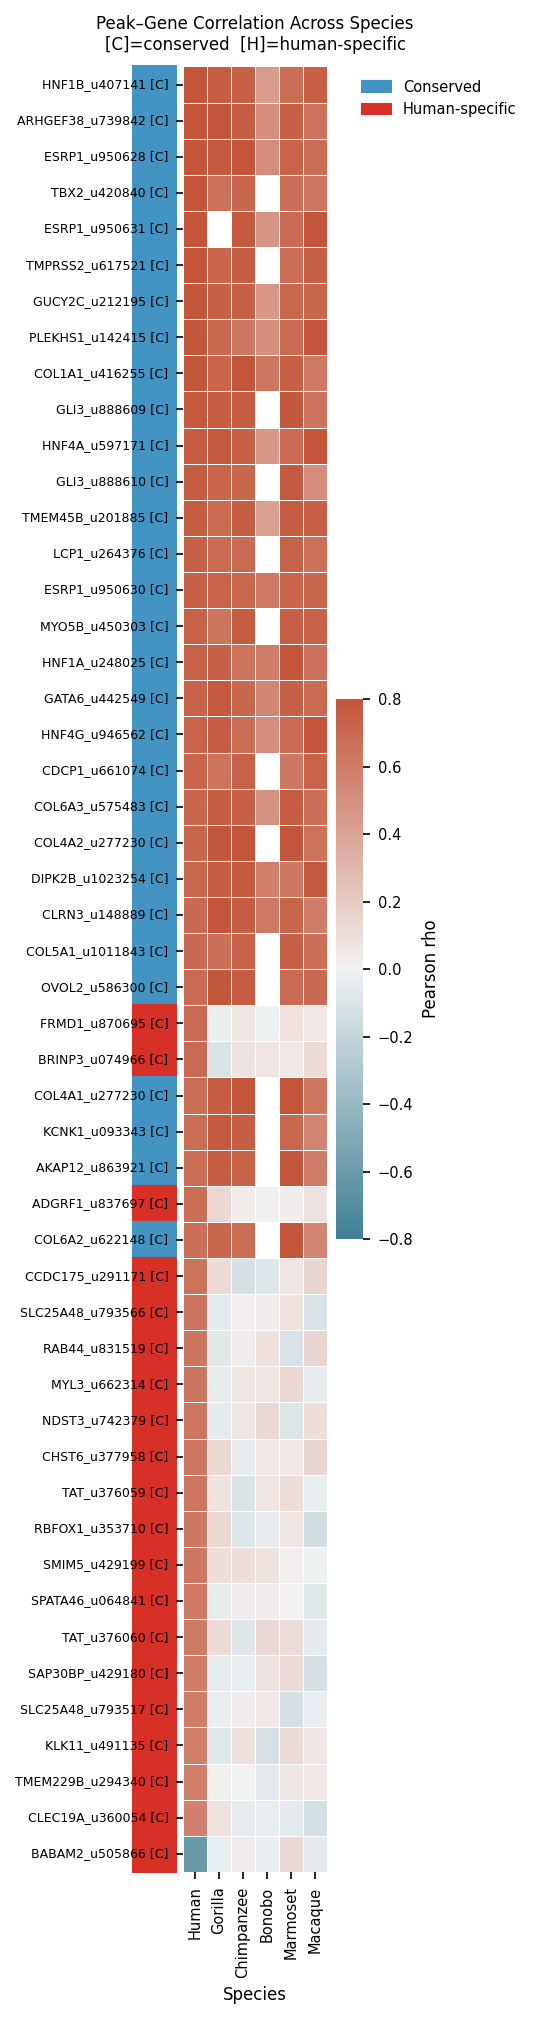

In [11]:
def label_link(row):
    """Short unique label: gene + peak_type + truncated peak_id."""
    pt = {"unified": "C", "human_specific": "H", "species_specific": "S", "rescued": "R"}.get(row["peak_type"], "?")
    pid_short = str(row["peak_id"]).replace("unified_", "u").replace("human_peak_", "h").replace("_peak_", "_")
    return f"{row['gene']}_{pid_short} [{pt}]"


# Combine top conserved + top human-specific for heatmap
top_cons = conserved.head(30).copy()
top_hs   = human_specific.head(20).copy()
top_all  = pd.concat([top_cons, top_hs]).drop_duplicates(subset=["peak_id", "gene"]).reset_index(drop=True)
top_all["label"] = top_all.apply(label_link, axis=1)

# Ensure labels are unique (append suffix if still duplicated)
for lbl in top_all["label"].value_counts().pipe(lambda s: s[s > 1]).index:
    for i, j in enumerate(top_all[top_all["label"] == lbl].index):
        top_all.loc[j, "label"] = f"{lbl}_{i}"

top_all["group"] = "conserved"
hs_keys = set(zip(top_hs["peak_id"], top_hs["gene"]))
top_all.loc[top_all.apply(lambda r: (r["peak_id"], r["gene"]) in hs_keys, axis=1), "group"] = "human_specific"

# Heatmap matrix
heat = top_all.set_index("label")[rho_cols].copy()
heat.columns = [c.replace("rho_", "") for c in heat.columns]
heat = heat.sort_values("Human", ascending=False)

# Row colors via dict (avoids reindex on non-unique index)
label_to_group = dict(zip(top_all["label"], top_all["group"]))
row_colors = pd.Series(
    {lbl: label_to_group.get(lbl, "conserved") for lbl in heat.index}
).map({"conserved": "#4393c3", "human_specific": "#d73027"})

fig, ax = plt.subplots(figsize=(3.5, len(heat) * 0.25 + 1))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    heat, ax=ax, cmap=cmap, center=0, vmin=-0.8, vmax=0.8,
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Pearson rho", "shrink": 0.6},
    yticklabels=True, xticklabels=True,
)

# Row colour strip
for i, label in enumerate(heat.index):
    ax.add_patch(plt.Rectangle(
        (-0.35, i), 0.3, 1, color=row_colors[label],
        transform=ax.get_yaxis_transform(), clip_on=False
    ))

ax.set_xlabel("Species", labelpad=4)
ax.set_ylabel("")
ax.set_title(
    "Peak–Gene Correlation Across Species\n[C]=conserved  [H]=human-specific",
    pad=8, fontsize=8
)
ax.tick_params(axis='y', labelsize=6)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color="#4393c3", label="Conserved"),
             Patch(color="#d73027", label="Human-specific")],
    loc="upper left", bbox_to_anchor=(1.15, 1.0), frameon=False
)

plt.tight_layout()
plt.savefig(OUT_DIR / "Fig2_top_links_heatmap.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "Fig2_top_links_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Cell-type level validation for top human-specific links

Load the ATAC and RNA pseudobulk data and for the top candidates show:
- ATAC accessibility across cell types (Human vs one NHP)
- RNA expression across cell types (Human vs one NHP)
- ATAC vs RNA scatter (each point = one cell type, coloured)

In [12]:
import anndata as ad
import scipy.sparse as sparse

# ── Load ATAC pseudobulk ──
def load_atac_pb(species):
    sp_dir = FRAGS_DIR / species
    counts = pd.read_parquet(sp_dir / "pseudobulk_counts.parquet").set_index("region_id")
    grp_df = pd.read_parquet(sp_dir / "pseudobulk_groups.parquet")
    grp_df["ct_donor"] = (
        grp_df["cell_type"].str.replace(" ", "_").str.replace("+", "p")
        + "__" + grp_df["donor"]
    )
    label_map = grp_df.set_index("label")["ct_donor"].to_dict()
    counts.columns = [label_map.get(c, c) for c in counts.columns]
    counts = counts.T.groupby(level=0).sum().T
    totals = counts.sum(axis=0)
    return np.log1p(counts.div(totals, axis=1) * 1e6)  # log1p CPM, peaks x groups


# ── Load RNA pseudobulk (recompute per species) ──
def get_pseudobulk(adata, group_cols, layer='logCPM', mode='sum'):
    group_key = '_'.join(group_cols)
    adata.obs[group_key] = adata.obs[group_cols].astype(str).agg('_'.join, axis=1)
    groups = adata.obs[group_key].unique()
    pb_dict, lib_sizes = {}, {}
    for group in groups:
        idx = np.where(adata.obs[group_key] == group)[0]
        X = adata[idx].X
        lib_sizes[group] = X.sum()
        agg = X.sum(0)
        pb_dict[group] = np.ravel(agg.toarray() if sparse.issparse(agg) else agg)
    pb = pd.DataFrame(pb_dict, index=adata.var_names).T
    totals = pd.Series(lib_sizes).reindex(pb.index)
    if layer == 'logCPM':
        pb = np.log1p(pb.div(totals, 0) * 1e6)
    return pb  # groups x genes


# ── Aggregate pseudobulk to cell-type mean (collapse donors) ──
def ct_mean_from_pb(pb_df, sep="__"):
    """Average pseudobulk samples to cell-type means. Index format: celltype__donor."""
    ct = pb_df.index.str.split(sep).str[0]
    return pb_df.groupby(ct).mean()


print("Helper functions defined.")

Helper functions defined.


In [13]:
# Select top N human-specific candidates to plot
N_CANDIDATES = 6
candidates = human_specific.head(N_CANDIDATES)[["peak_id", "gene", "peak_type", "rho_Human"] + nhp_rho_cols]
print("Candidates for cell-type level plots:")
print(candidates.to_string(index=False))

Candidates for cell-type level plots:
       peak_id     gene peak_type  rho_Human  rho_Gorilla  rho_Chimpanzee  rho_Bonobo  rho_Marmoset  rho_Macaque
unified_870695    FRMD1   unified   0.686968    -0.024823        0.068554   -0.009928      0.083577     0.037835
unified_074966   BRINP3   unified   0.683878    -0.094262        0.069019    0.061804      0.047621     0.121147
unified_837697   ADGRF1   unified   0.669309     0.135124        0.035389    0.008094      0.021232     0.070267
unified_291171  CCDC175   unified   0.648718     0.120326       -0.126056   -0.086506      0.057875     0.137763
unified_793566 SLC25A48   unified   0.643360    -0.056396        0.012548    0.028801      0.085473    -0.100793
unified_831519    RAB44   unified   0.634519    -0.074616        0.026417    0.093162     -0.105900     0.146365


In [14]:
# Load data for Human and one representative NHP (Gorilla, closest relative)
COMPARE_SP = "Gorilla"

print(f"Loading ATAC pseudobulk for Human and {COMPARE_SP}...")
atac_h  = load_atac_pb("Human")
atac_nhp = load_atac_pb(COMPARE_SP)

print("Loading RNA h5ad...")
rna_adata = ad.read_h5ad(RNA_PATH)

def make_rna_ct(adata, species):
    sub = adata[adata.obs["Species"] == species].copy()
    sub.obs["_ct_donor"] = (
        sub.obs["cell_type_initial"].astype(str).str.replace(" ", "_").str.replace("+", "p")
        + "__" + sub.obs["Individual"].astype(str)
    )
    pb = get_pseudobulk(sub, ["_ct_donor"], layer="logCPM")
    return ct_mean_from_pb(pb)

print(f"Building RNA pseudobulk cell-type means...")
rna_h   = make_rna_ct(rna_adata, "Human")
rna_nhp = make_rna_ct(rna_adata, COMPARE_SP)

# Cell-type means for ATAC
atac_h_ct  = ct_mean_from_pb(atac_h.T).T   # peaks x cell_types
atac_nhp_ct = ct_mean_from_pb(atac_nhp.T).T

print(f"Human:    ATAC {atac_h_ct.shape}, RNA {rna_h.shape}")
print(f"{COMPARE_SP}: ATAC {atac_nhp_ct.shape}, RNA {rna_nhp.shape}")

Loading ATAC pseudobulk for Human and Gorilla...


/tmp/ipykernel_3220949/1527564234.py:10: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  grp_df["cell_type"].str.replace(" ", "_").str.replace("+", "p")
/tmp/ipykernel_3220949/1527564234.py:10: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  grp_df["cell_type"].str.replace(" ", "_").str.replace("+", "p")


Loading RNA h5ad...
Building RNA pseudobulk cell-type means...


/tmp/ipykernel_3220949/2033875209.py:14: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  sub.obs["cell_type_initial"].astype(str).str.replace(" ", "_").str.replace("+", "p")
/tmp/ipykernel_3220949/2033875209.py:14: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  sub.obs["cell_type_initial"].astype(str).str.replace(" ", "_").str.replace("+", "p")


Human:    ATAC (1039336, 32), RNA (32, 12785)
Gorilla: ATAC (1013198, 31), RNA (33, 12785)


In [25]:
def plot_link_celltypes(peak_id, gene, ax_atac_h, ax_rna_h, ax_scatter_h,
                         ax_atac_nhp, ax_rna_nhp, ax_scatter_nhp,
                         atac_h_ct, rna_h, atac_nhp_ct, rna_nhp, nhp_label):
    """Six-panel plot for one peak-gene link."""

    def _get_vectors(atac_ct, rna_ct, pid, g):
        if pid not in atac_ct.index:
            return None, None, None
        if g not in rna_ct.columns:
            return None, None, None
        shared_ct = sorted(set(atac_ct.columns) & set(rna_ct.index))
        a = atac_ct.loc[pid, shared_ct].values.astype(float)
        r = rna_ct.loc[shared_ct, g].values.astype(float)
        return a, r, shared_ct

    for is_nhp, (atac_ct, rna_ct, ax_a, ax_r, ax_s, sp_label) in enumerate([
        (atac_h_ct,   rna_h,   ax_atac_h,   ax_rna_h,   ax_scatter_h,   "Human"),
        (atac_nhp_ct, rna_nhp, ax_atac_nhp, ax_rna_nhp, ax_scatter_nhp, nhp_label),
    ]):
        a, r, cts = _get_vectors(atac_ct, rna_ct, peak_id, gene)

        if a is None:
            for axi in [ax_a, ax_r, ax_s]:
                axi.text(0.5, 0.5, "No data", ha="center", va="center",
                         transform=axi.transAxes, fontsize=7)
                axi.axis("off")
            continue

        colors = [CT_COLOR_LOOKUP.get(ct, "#aaaaaa") for ct in cts]
        order  = np.argsort(a)[::-1]
        cts_ord = [cts[i] for i in order]
        a_ord   = a[order]
        c_ord   = [CT_COLOR_LOOKUP.get(ct, "#aaaaaa") for ct in cts_ord]

        # ATAC bar
        ax_a.barh(range(len(cts_ord)), a_ord, color=c_ord, height=0.8, edgecolor="none")
        ax_a.set_yticks(range(len(cts_ord)))
        ax_a.set_yticklabels(cts_ord, fontsize=5.5)
        ax_a.set_xlabel("ATAC log1p(CPM)", fontsize=6)
        ax_a.set_title(f"{sp_label} — {peak_id[:22]}", fontsize=7)
        ax_a.invert_yaxis()

        # RNA bar (same cell type order as ATAC)
        rna_ordered = rna_ct.loc[cts_ord, gene].values.astype(float)
        ax_r.barh(range(len(cts_ord)), rna_ordered,
                  color=c_ord, height=0.8, edgecolor="none")
        ax_r.set_yticks([])
        ax_r.set_xlabel("RNA logCPM", fontsize=6)
        ax_r.set_title(f"{gene} expression", fontsize=7)
        ax_r.invert_yaxis()

        # Scatter ATAC vs RNA
        for i, ct in enumerate(cts):
            ax_s.scatter(a[i], r[i], s=22,
                         color=CT_COLOR_LOOKUP.get(ct, "#aaaaaa"),
                         zorder=3, edgecolors="white", linewidths=0.3)
        if len(a) > 2 and a.std() > 1e-6:
            m, b = np.polyfit(a, r, 1)
            xr = np.array([a.min(), a.max()])
            ax_s.plot(xr, m * xr + b, color="#444444", lw=1, ls="--", zorder=2)
            rho = np.corrcoef(a, r)[0, 1]
            ax_s.set_title(f"rho = {rho:.2f}", fontsize=7)
        ax_s.set_xlabel("ATAC log1p(CPM)", fontsize=6)
        ax_s.set_ylabel("RNA logCPM", fontsize=6)

print("Plot function defined.")

Plot function defined.


Shared cell types (Human ATAC ∩ Human RNA): 32


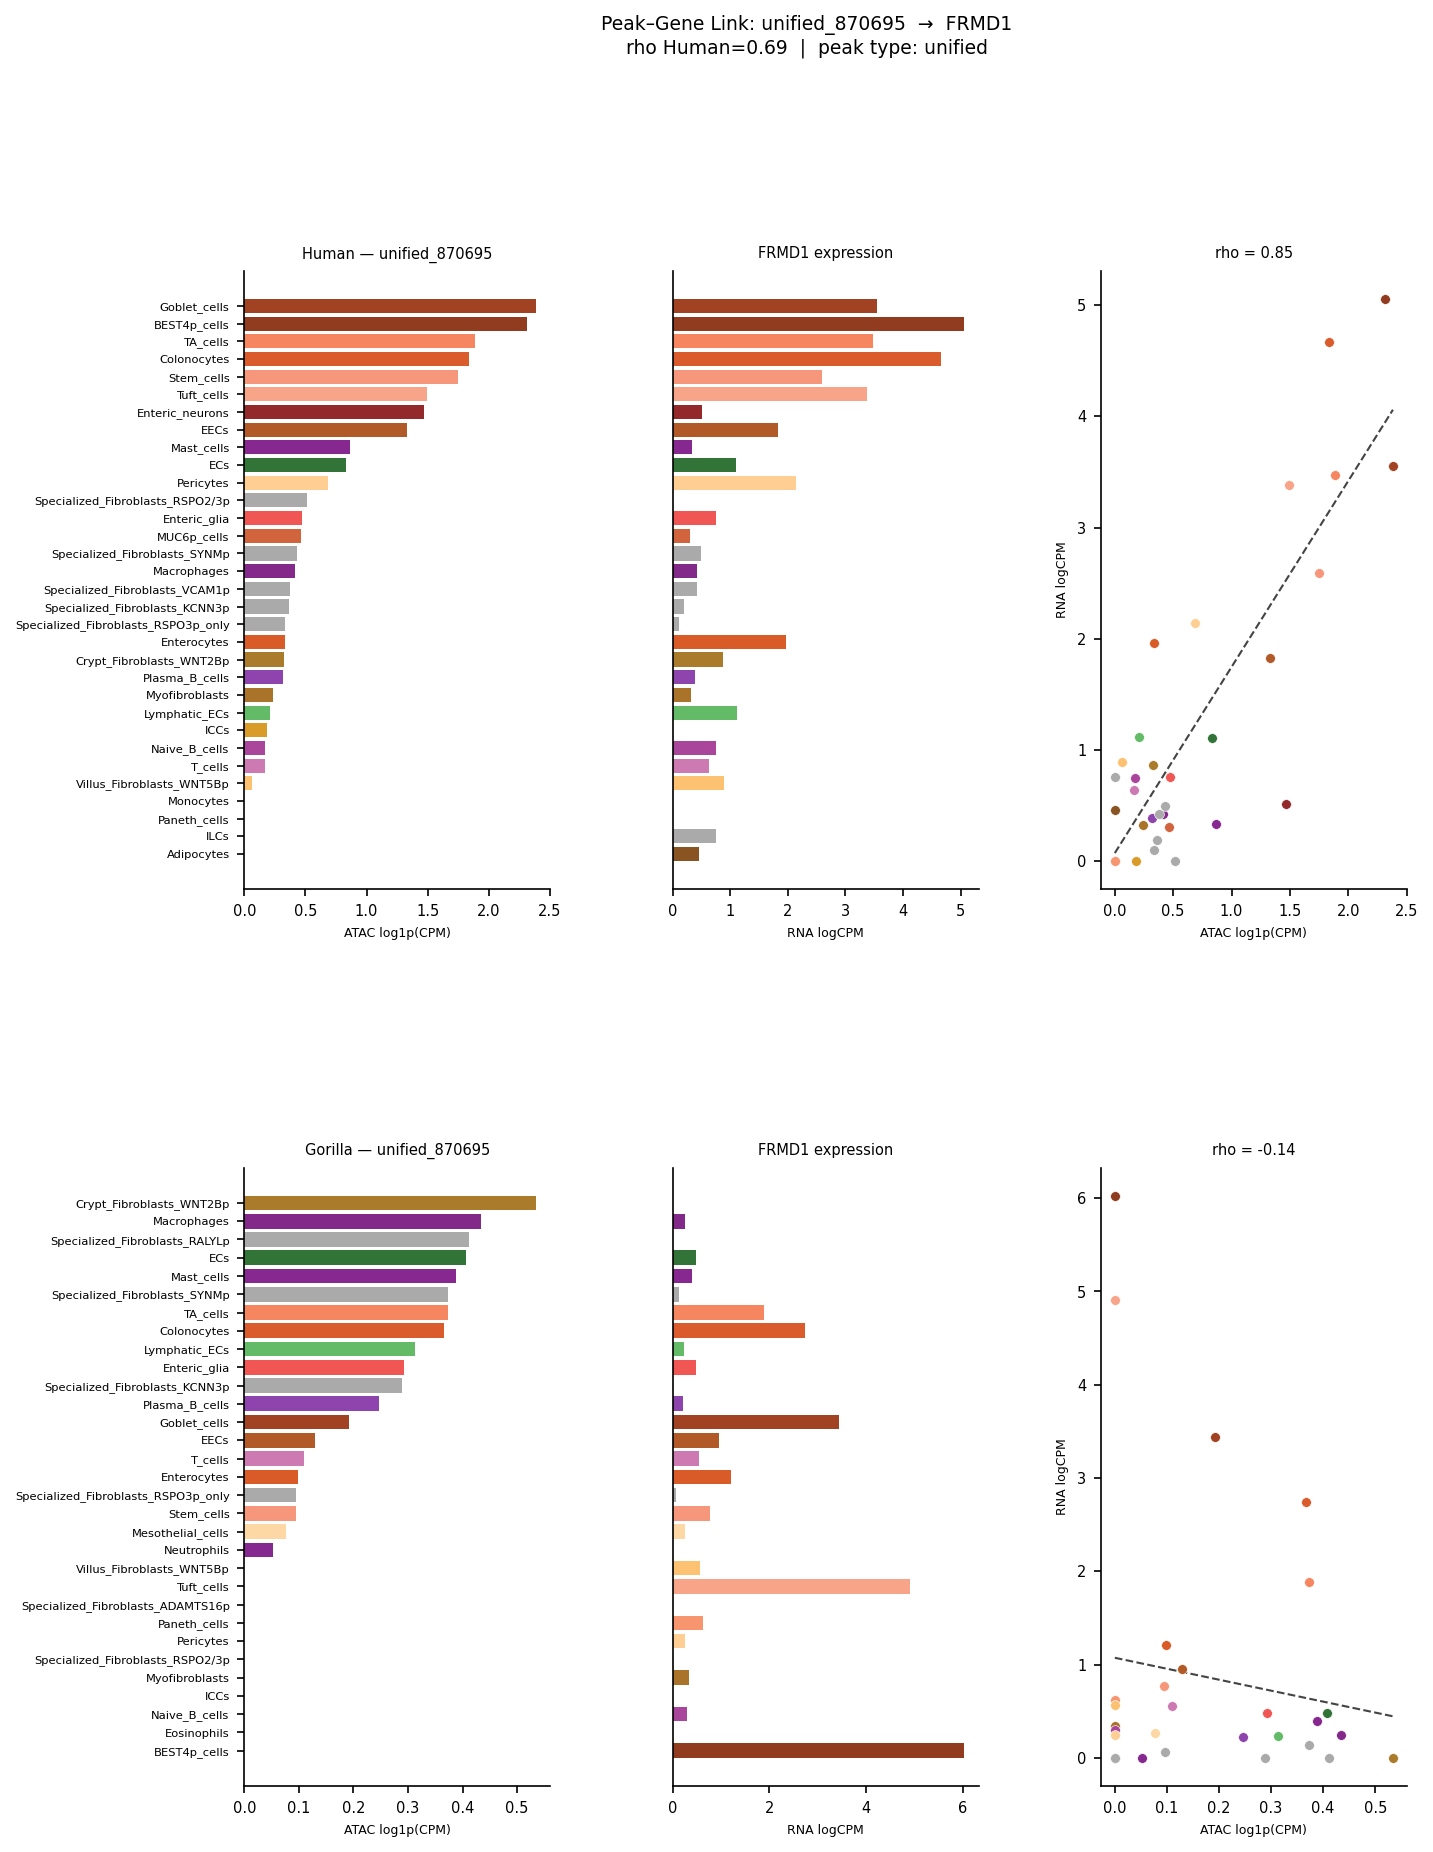

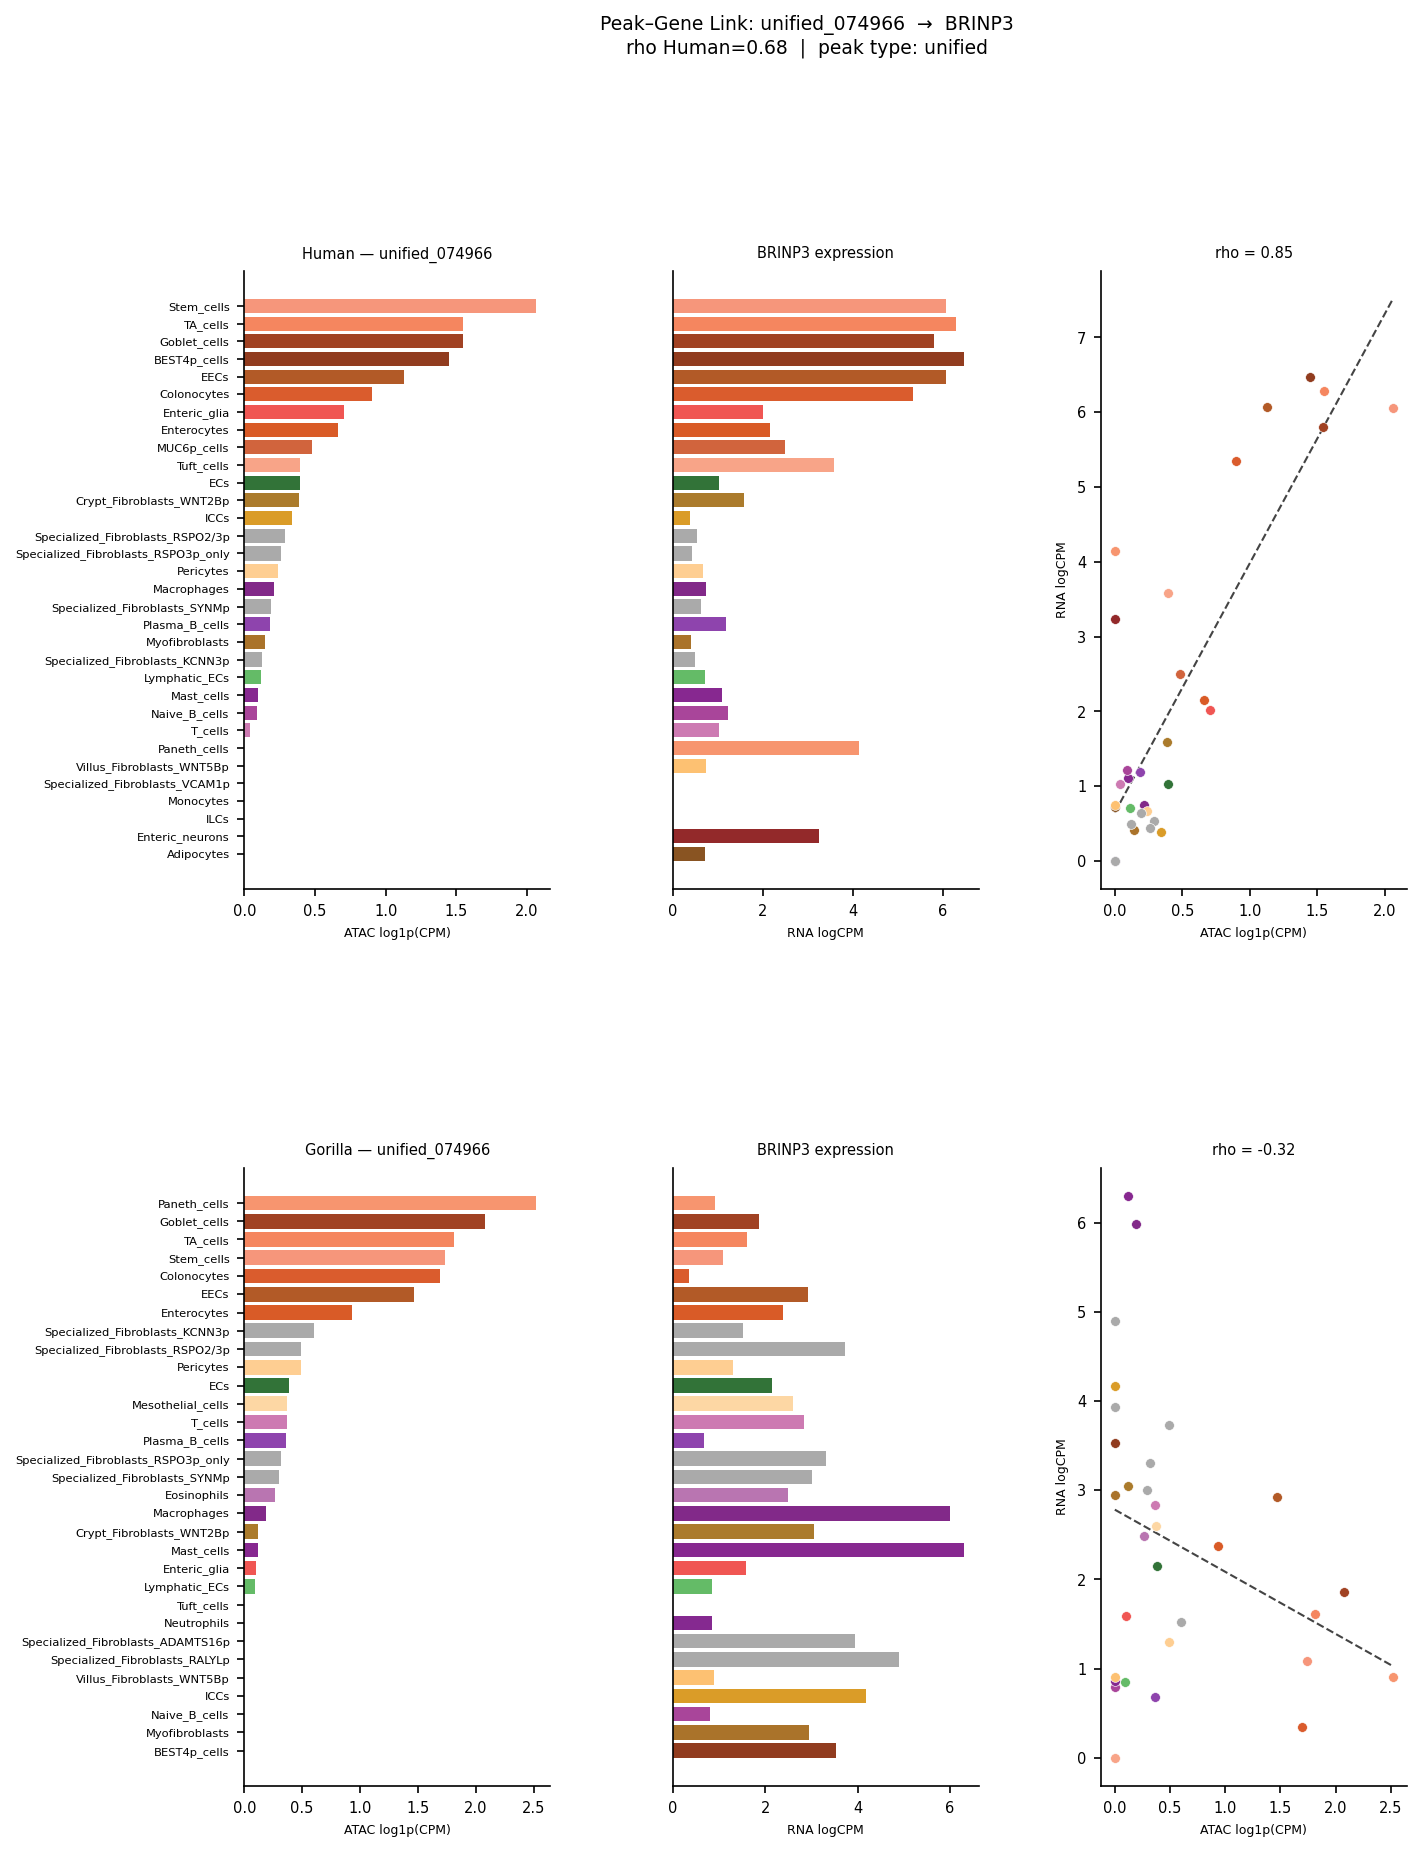

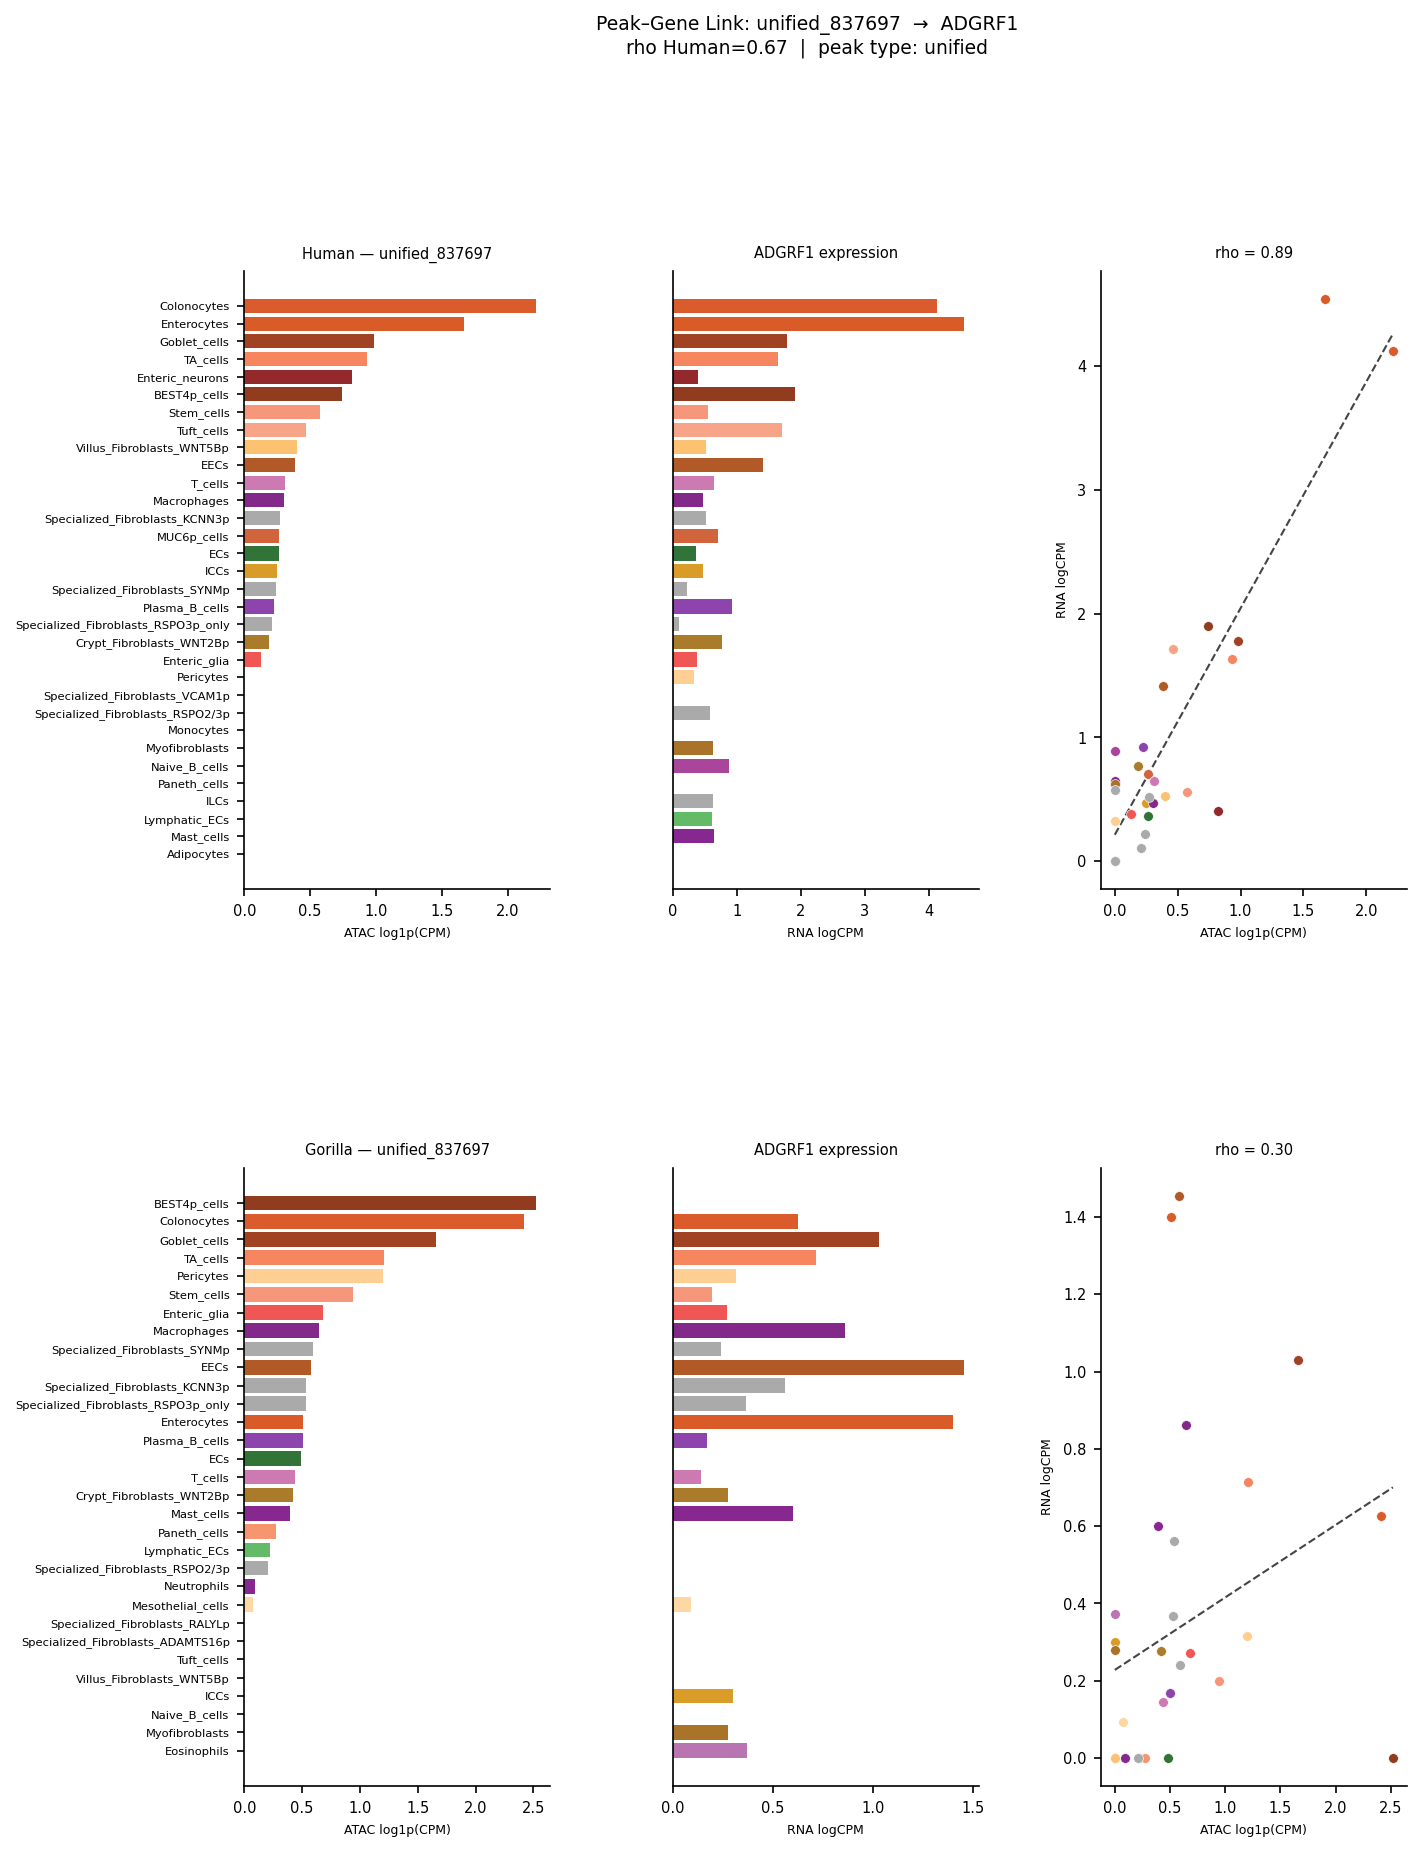

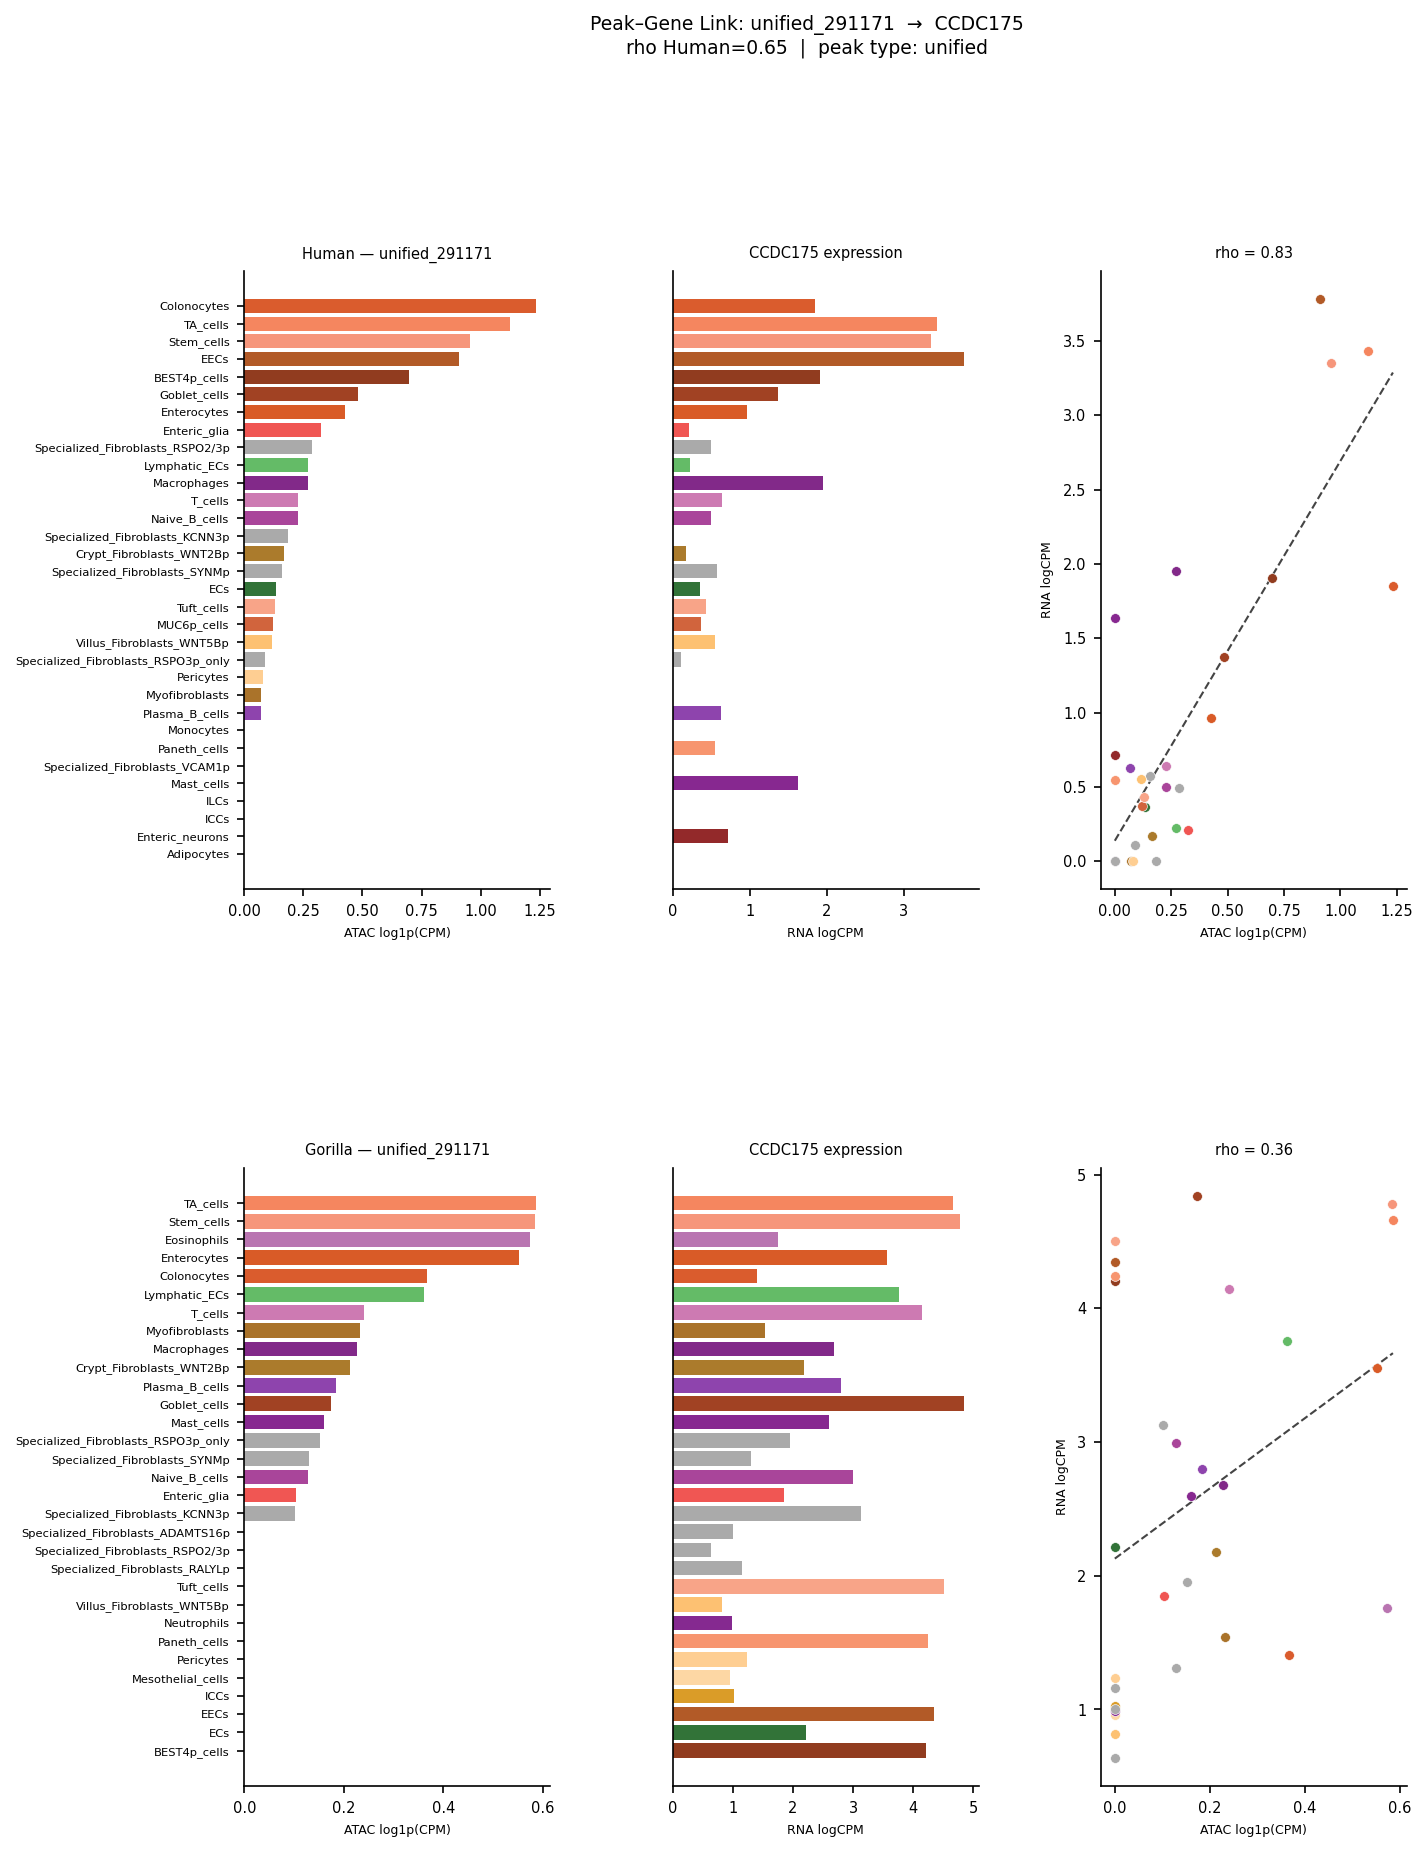

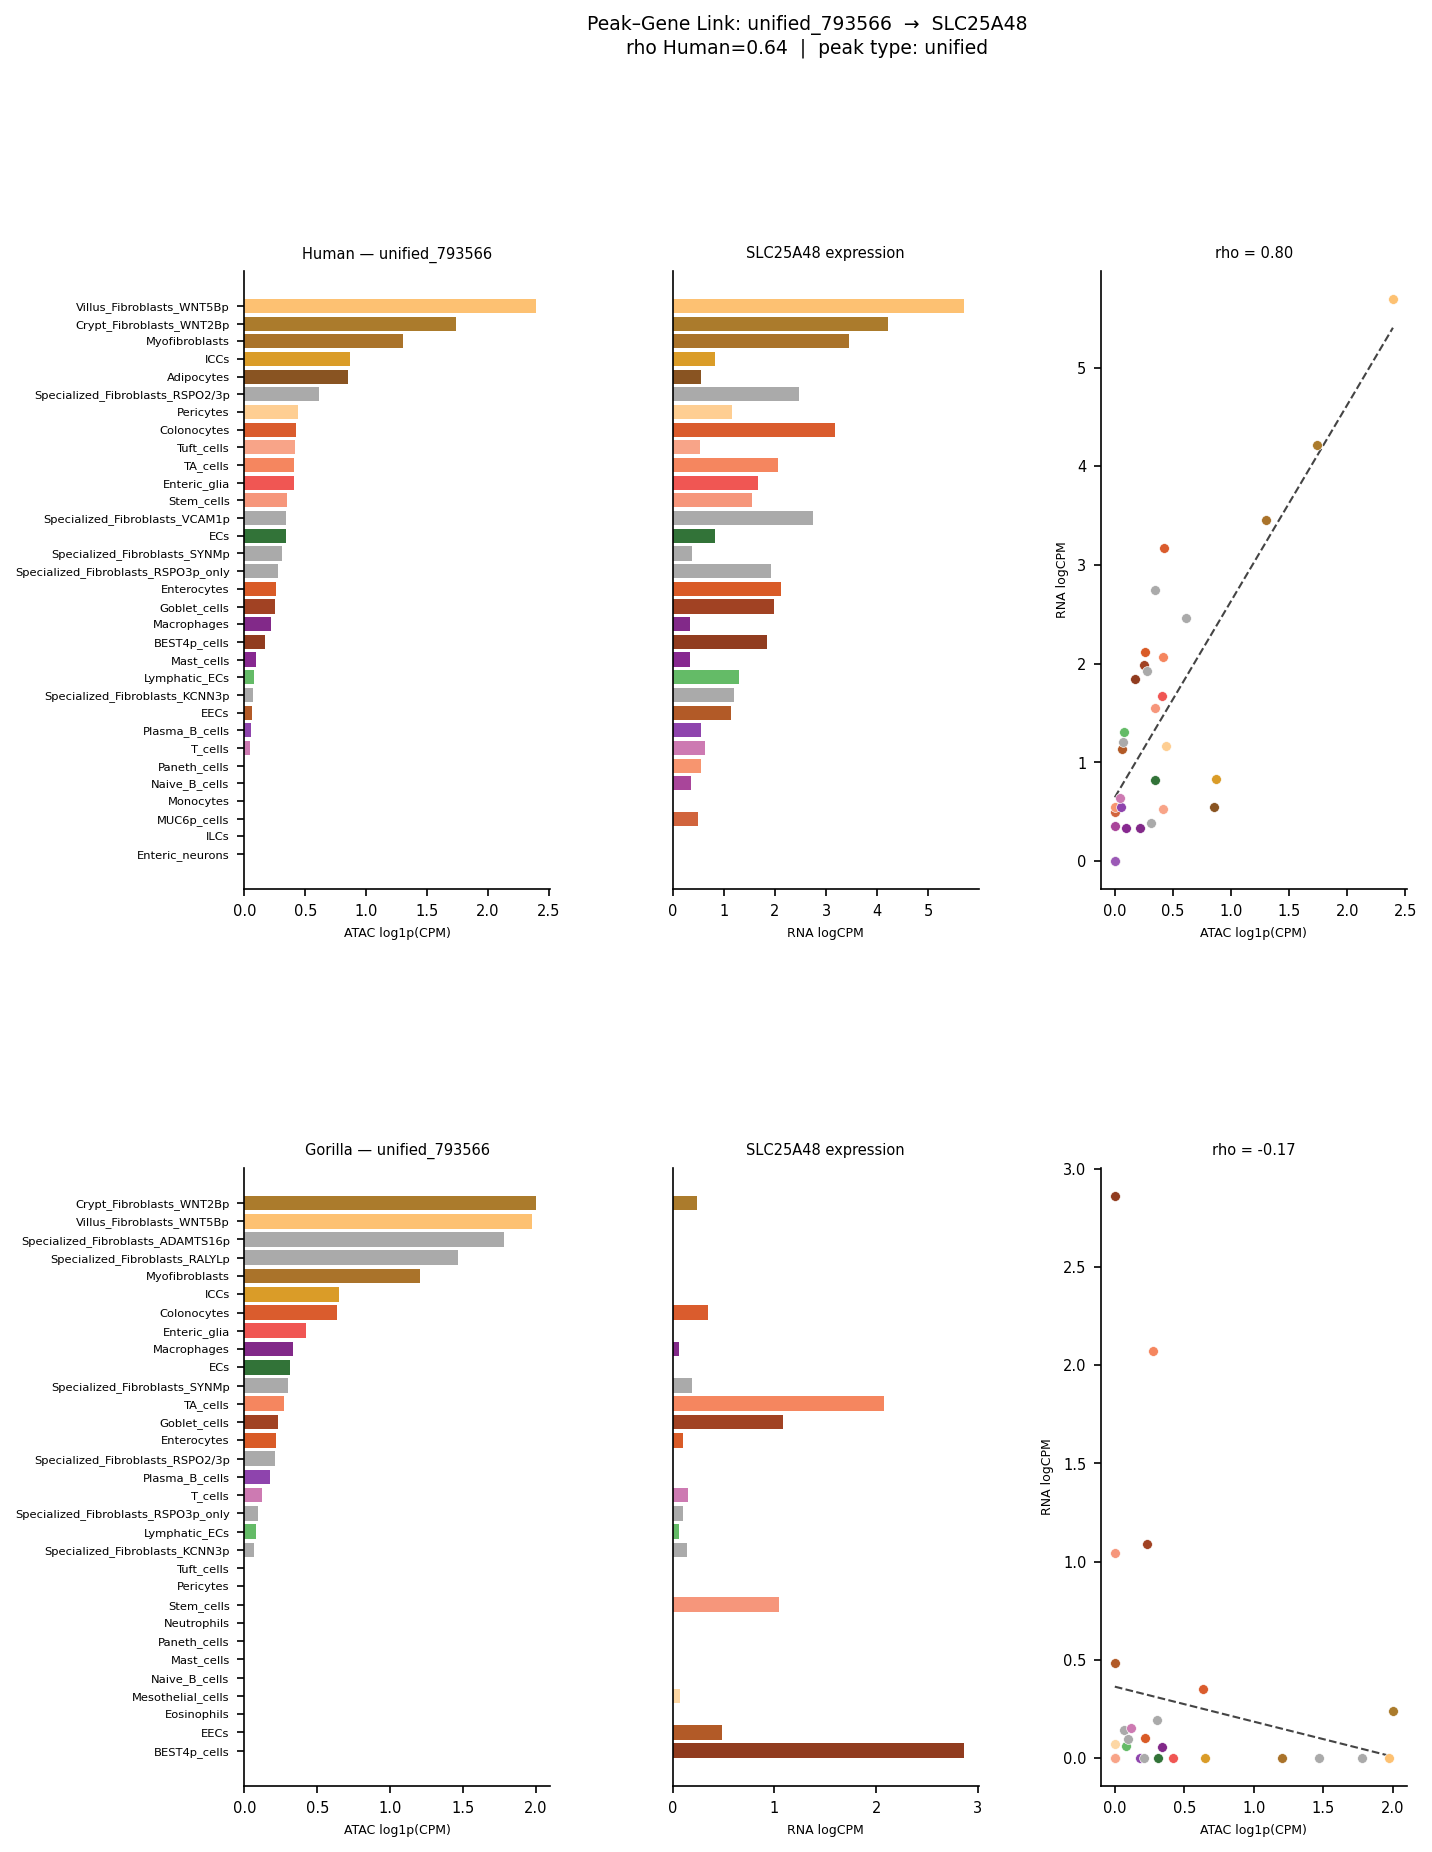

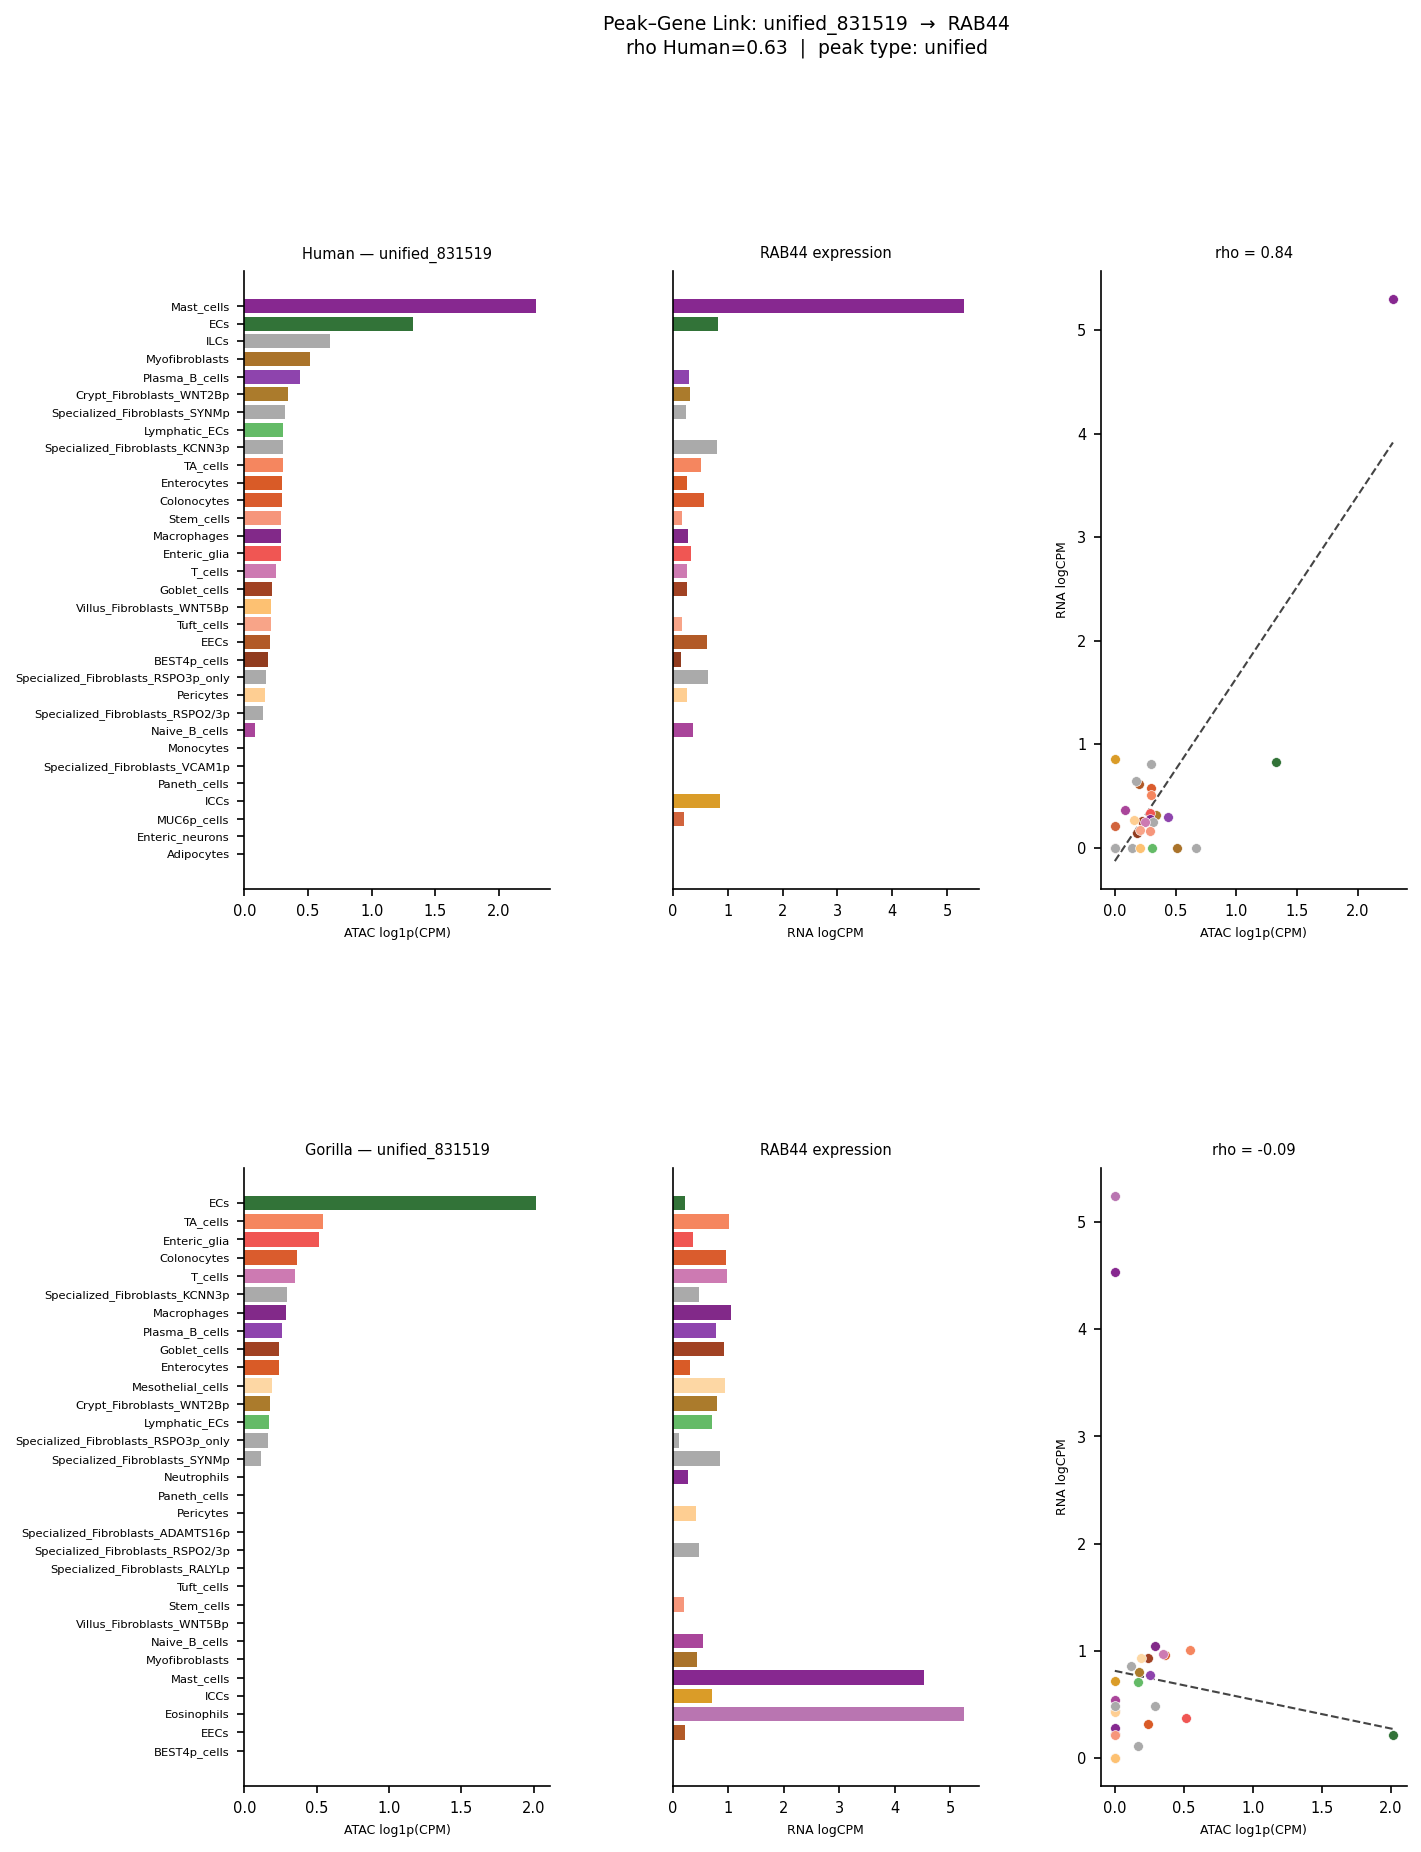

In [27]:
# Determine shared cell types for layout
shared_cts = sorted(set(atac_h_ct.columns) & set(rna_h.index))
n_ct = len(shared_cts)
print(f"Shared cell types (Human ATAC ∩ Human RNA): {n_ct}")

# Plot each candidate
for _, row in candidates.iterrows():
    pid  = row["peak_id"]
    gene = row["gene"]
    rho_h = row["rho_Human"]

    # 2 rows (Human, NHP) × 3 cols (ATAC bar, RNA bar, scatter)
    fig = plt.figure(figsize=(10, 2 * (n_ct * 0.18 + 0.8)), constrained_layout=False)
    fig.suptitle(
        f"Peak–Gene Link: {pid}  →  {gene}\n"
        f"rho Human={rho_h:.2f}  |  peak type: {row['peak_type']}",
        fontsize=9, y=1.01
    )

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

    ax_ah  = fig.add_subplot(gs[0, 0])
    ax_rh  = fig.add_subplot(gs[0, 1])
    ax_sh  = fig.add_subplot(gs[0, 2])
    ax_an  = fig.add_subplot(gs[1, 0])
    ax_rn  = fig.add_subplot(gs[1, 1])
    ax_sn  = fig.add_subplot(gs[1, 2])

    plot_link_celltypes(
        pid, gene,
        ax_ah, ax_rh, ax_sh,
        ax_an, ax_rn, ax_sn,
        atac_h_ct, rna_h,
        atac_nhp_ct, rna_nhp,
        COMPARE_SP
    )

    # Row labels
    #fig.text(0.01, 0.75, "Human",      va="center", ha="left", fontsize=8,
    #         color=SPECIES_COLORS["Human"],      rotation=90, fontweight="bold")
    #fig.text(0.01, 0.25, COMPARE_SP, va="center", ha="left", fontsize=8,
    #         color=SPECIES_COLORS[COMPARE_SP], rotation=90, fontweight="bold")

    safe_pid = str(pid).replace("/", "_")[:40]
    plt.savefig(OUT_DIR / f"Fig3_celltype_{safe_pid}_{gene}.pdf", bbox_inches="tight")
    plt.savefig(OUT_DIR / f"Fig3_celltype_{safe_pid}_{gene}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Summary: top conserved links cell-type view

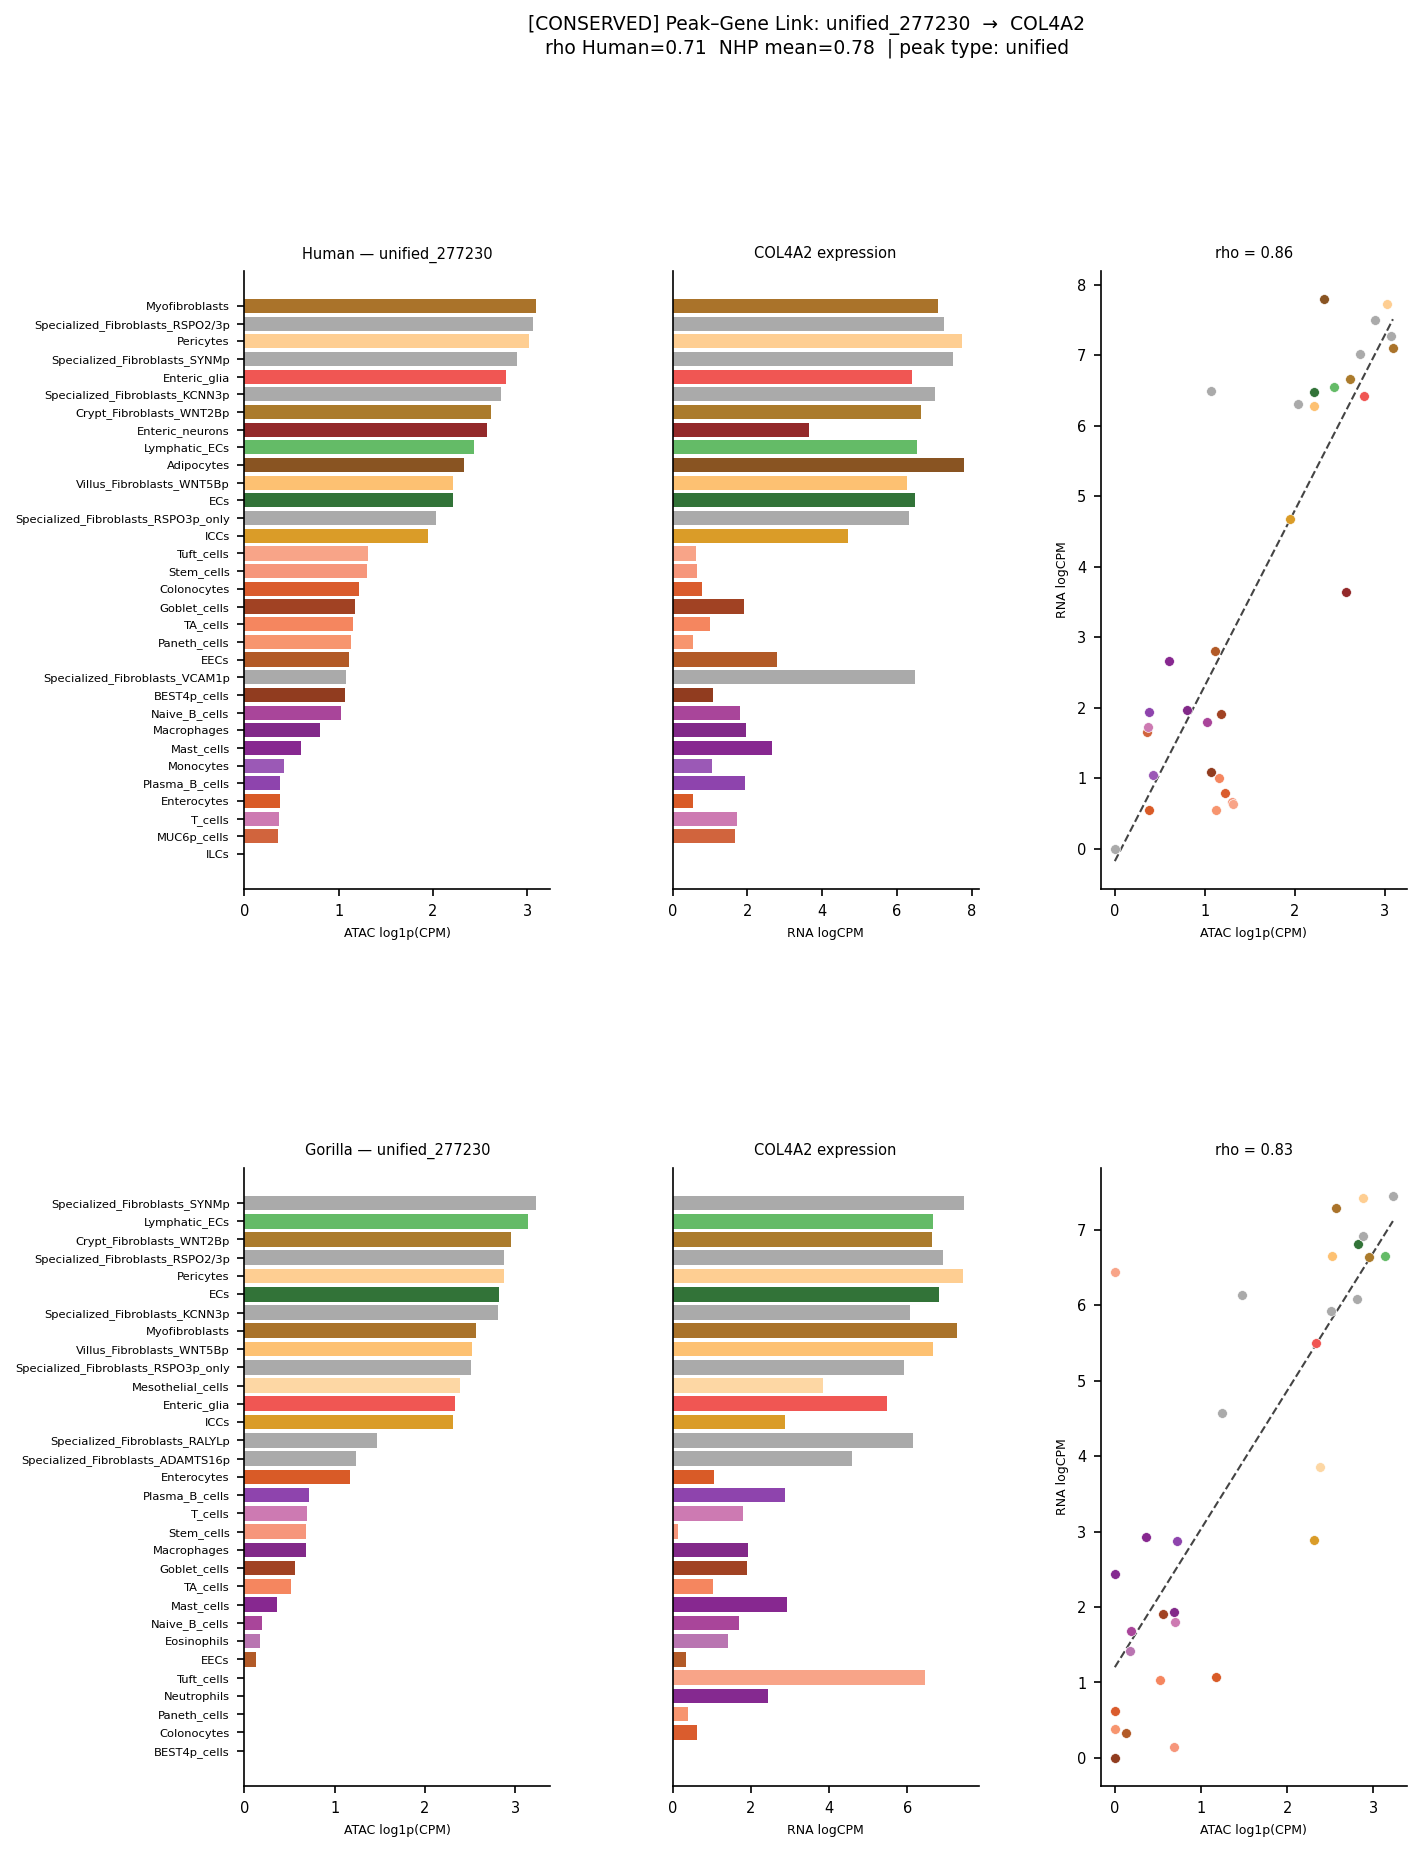

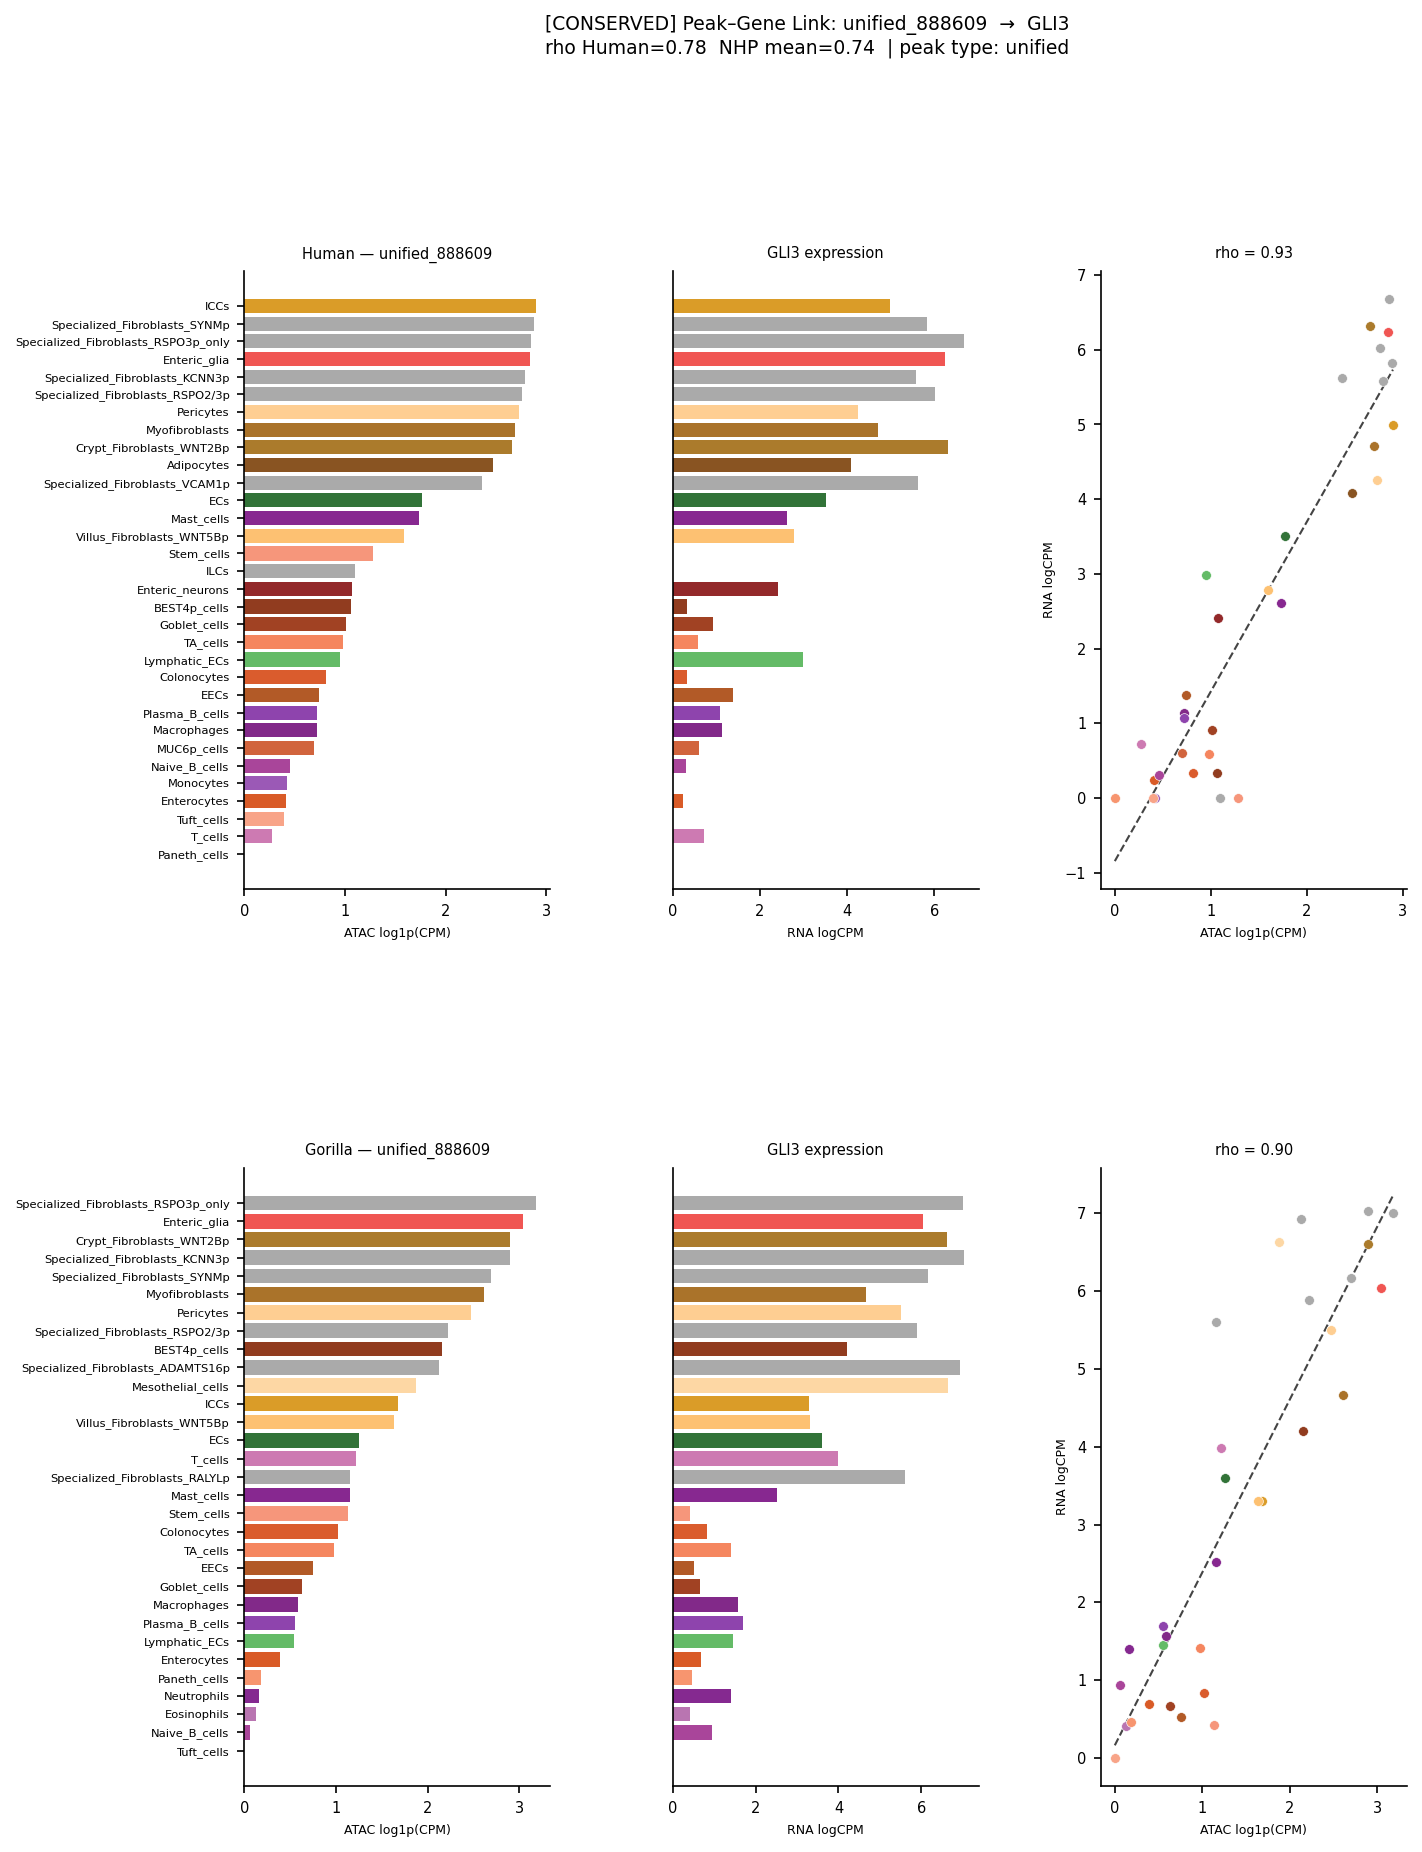

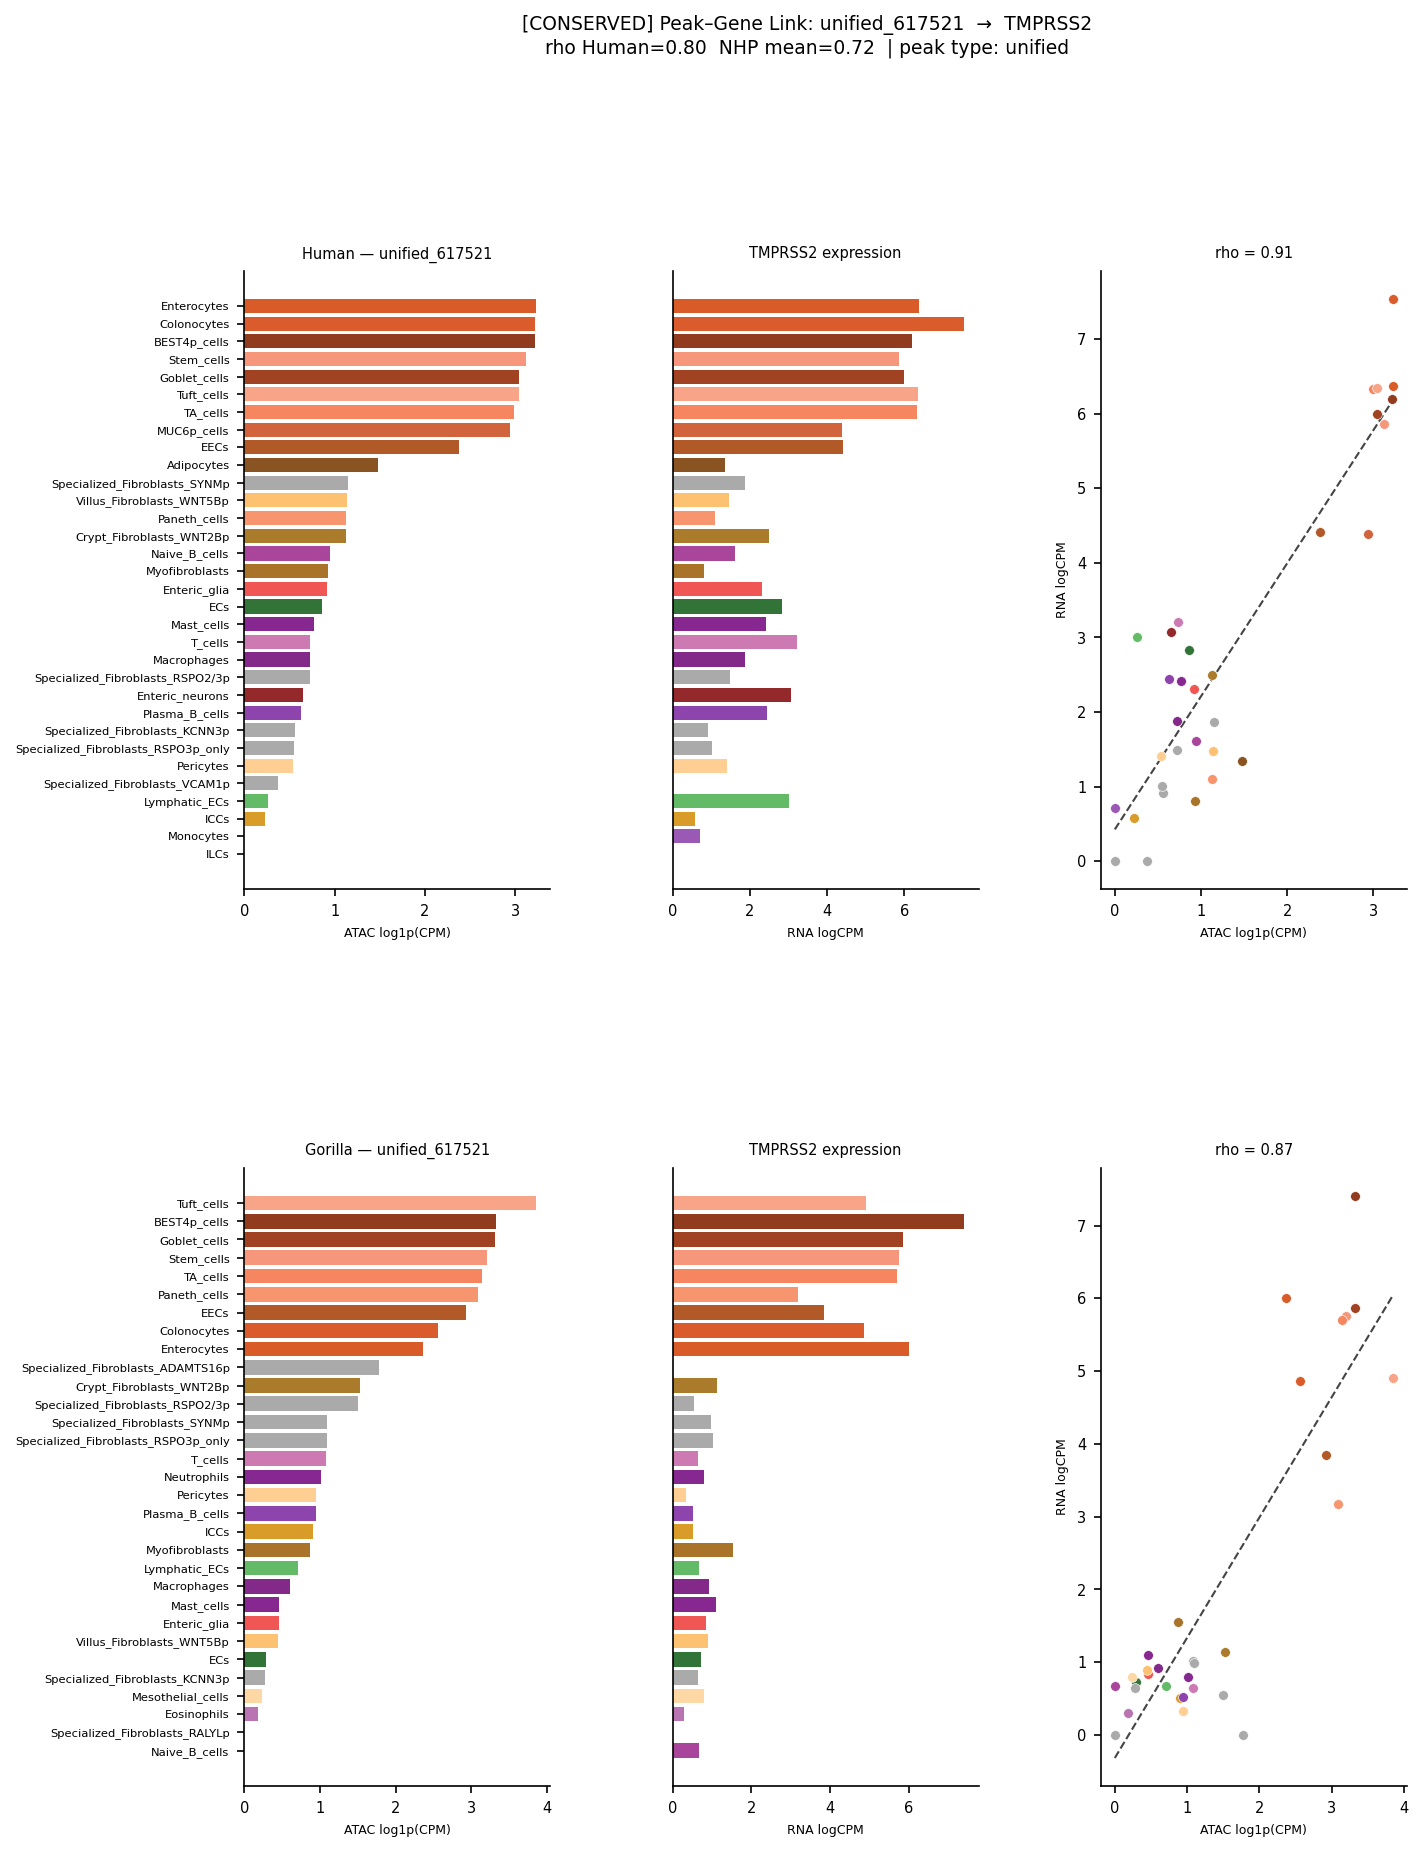

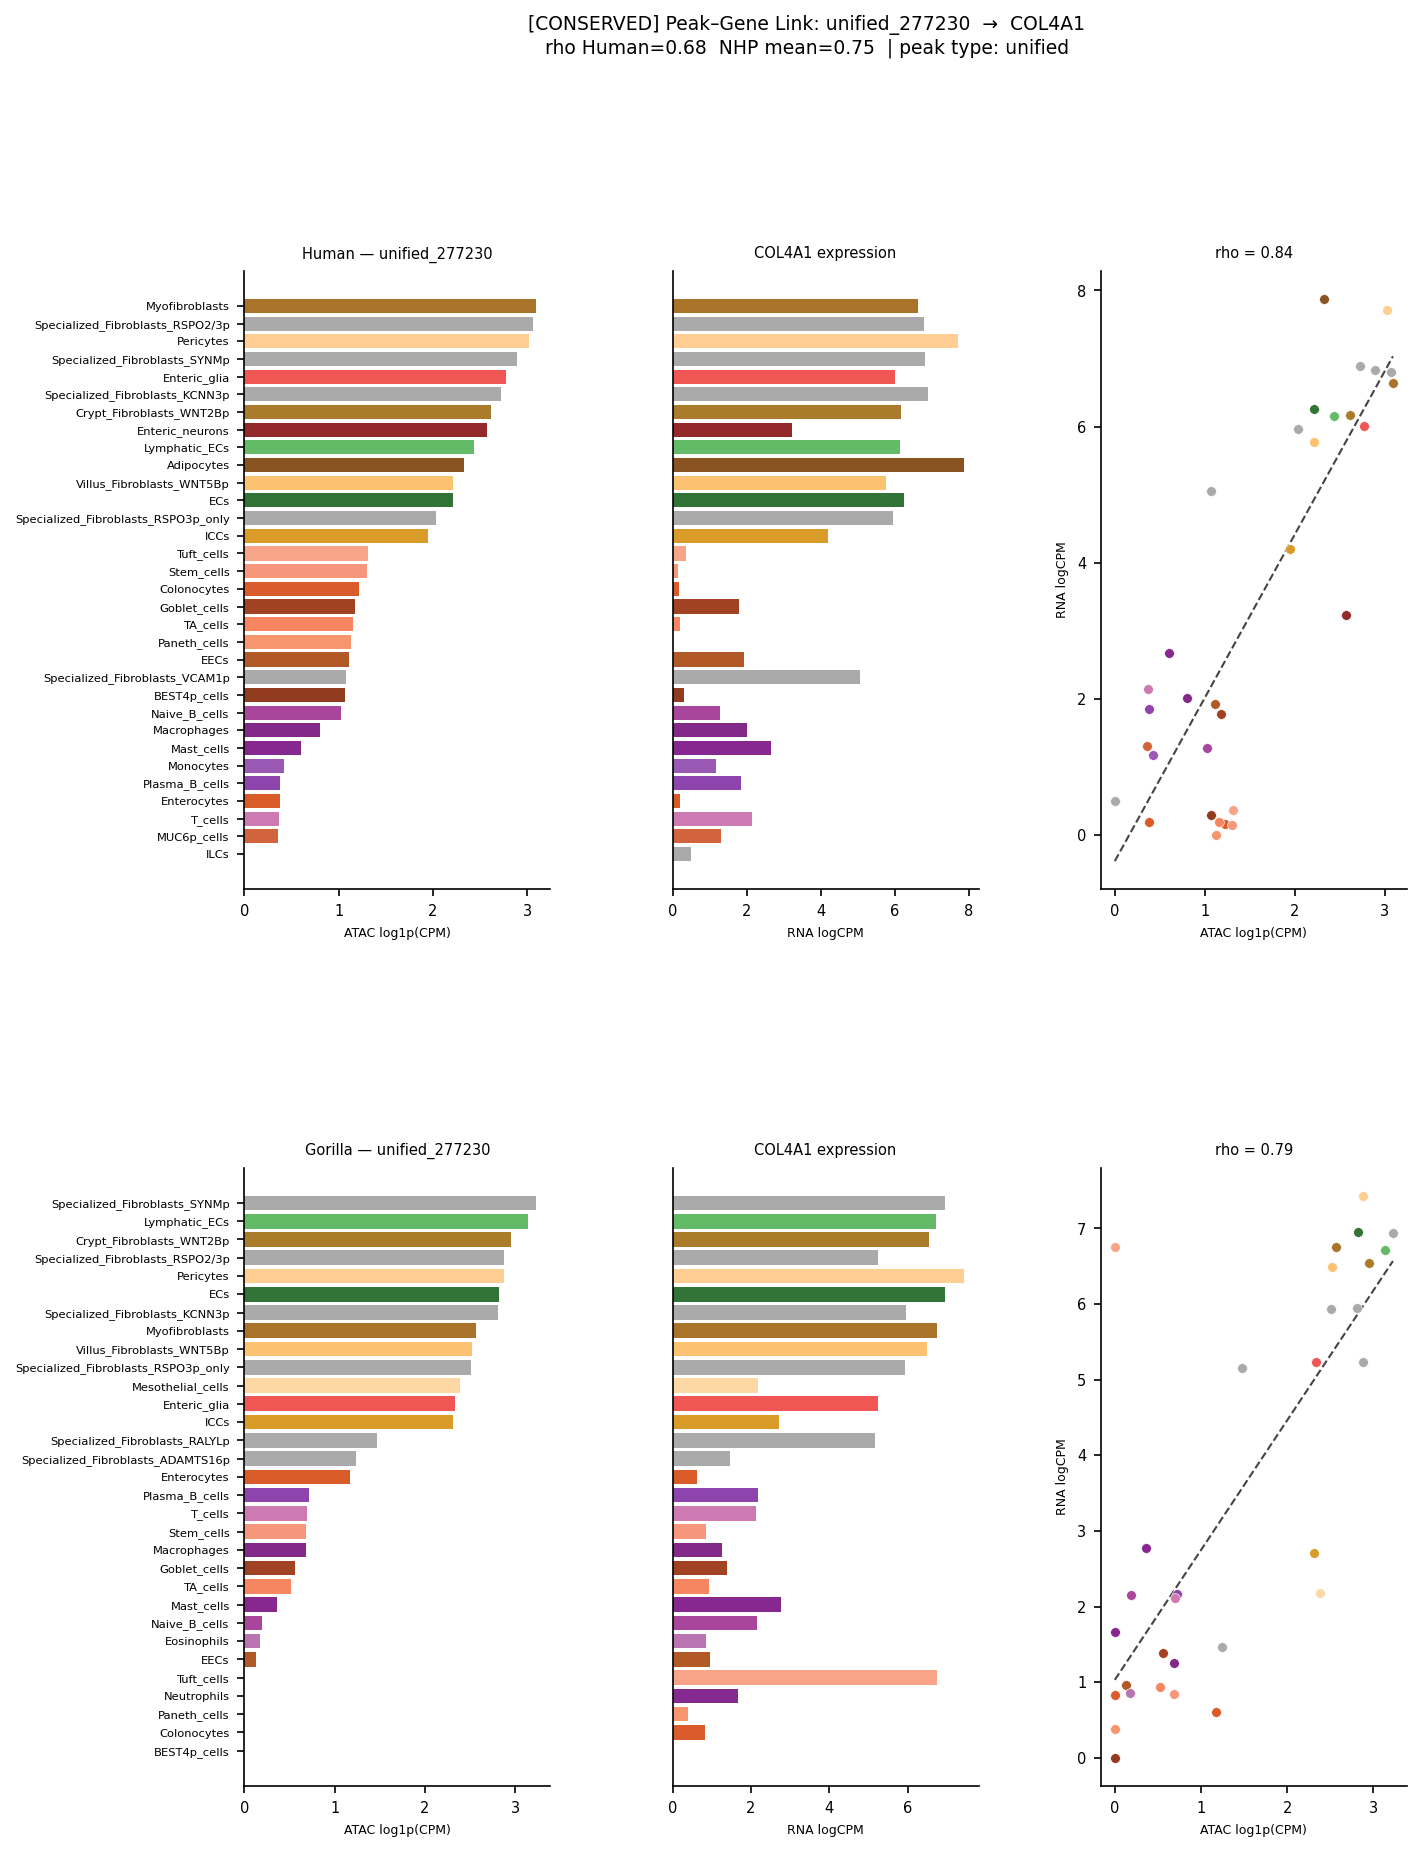

In [28]:
# Same plot for top conserved links
N_CONSERVED = 4
for _, row in conserved.head(N_CONSERVED).iterrows():
    pid  = row["peak_id"]
    gene = row["gene"]
    rho_h = row["rho_Human"]

    fig = plt.figure(figsize=(10, 2 * (n_ct * 0.18 + 0.8)), constrained_layout=False)
    fig.suptitle(
        f"[CONSERVED] Peak–Gene Link: {pid}  →  {gene}\n"
        f"rho Human={rho_h:.2f}  NHP mean={row['nhp_rho_mean']:.2f}  | peak type: {row['peak_type']}",
        fontsize=9, y=1.01
    )

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)
    axes_ = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

    plot_link_celltypes(
        pid, gene,
        *axes_[:3], *axes_[3:],
        atac_h_ct, rna_h,
        atac_nhp_ct, rna_nhp,
        COMPARE_SP
    )

    #fig.text(0.01, 0.75, "Human",      va="center", ha="left", fontsize=8,
    #         color=SPECIES_COLORS["Human"],      rotation=90, fontweight="bold")
    #fig.text(0.01, 0.25, COMPARE_SP, va="center", ha="left", fontsize=8,
    #         color=SPECIES_COLORS[COMPARE_SP], rotation=90, fontweight="bold")

    safe_pid = str(pid).replace("/", "_")[:40]
    plt.savefig(OUT_DIR / f"Fig4_conserved_{safe_pid}_{gene}.pdf", bbox_inches="tight")
    plt.show()